<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Graph Domain, equation 2.2


In [65]:
import numpy as np

# Function to create the circulant matrix Z
def circulant_Z(N):
    Z = np.zeros((N, N), dtype=int)
    for i in range(N-1):
        Z[i, i+1] = 1
    Z[N-1, 0] = 1
    return Z

# Function to create the Fourier matrix F
def Fourier_F(N):
    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    F = (1/np.sqrt(N)) * w**(k*l)
    return F, w

# Function to create diagonal matrix D_F
def diagonal_D_F(N, w):
    exponents = -np.arange(N)
    D_F = np.diag(w**exponents)
    return D_F

# Example usage
N = 5
Z = circulant_Z(N)
F, w = Fourier_F(N)
D_F = diagonal_D_F(N, w)

# Check Z = F^H @ D_F @ F
Z_reconstructed = np.conjugate(F.T) @ D_F @ F

print("Original Z:")
print(Z)

print("\nReconstructed Z (F^H D_F F):")
print(np.round(Z_reconstructed.real, 10))  # Round and take real part

# Check if they are close
if np.allclose(Z, Z_reconstructed, atol=1e-10):
    print("\nCheck passed ✅: Z = F^H @ D_F @ F")
else:
    print("\nCheck failed ❌")


Original Z:
[[0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [1 0 0 0 0]]

Reconstructed Z (F^H D_F F):
[[ 0.  1.  0. -0.  0.]
 [-0.  0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.]
 [ 1.  0.  0.  0.  0.]]

Check passed ✅: Z = F^H @ D_F @ F


#Rationale for Sinusoids Supporting the Spectral Framework of Fractional DFTs
Let $\mathbf{G}_{\theta \in \mathbb{Z}}$ be the family  extends the classical harmonic analysis framework of the DFT by introducing a tunable parameter $\theta$

$\begin{equation}
\mathbf{G}_\theta = \left[ w^{\left(k - \frac{\theta}{2}\right)\left(\ell - \frac{\theta}{2}\right)} \right]_{k,\ell=0}^{N-1},
\end{equation}$
$\theta\in\{0,1,\cdots,2N-1\},w = e^{-j \frac{2\pi}{N}}$

$\begin{align*}
\mathbf{G}_\theta^2 &=
\begin{cases}
\mathbf{J}_{\theta + 1} \oplus  (-1)^\theta \mathbf{J}_{N - \theta - 1}  & \text{for } 0 \leq \theta < N, \\[6pt]
 (-1)^\theta \, \mathbf{J}_{\theta - N+ 1} \oplus \mathbf{J}_{2N - \theta - 1}, & \text{for } N \leq \theta < 2N,
\end{cases}\\
\mathbf{G}_\theta^4 &= I,
\end{align*}$

where:

-  $J$ is the antidiagonal matrix,



In [ ]:
import numpy as np
#parameter
N = 7
theta = 4
# Construct matrix G_theta with normalization 1/sqrt(N)
def G_theta(N, theta):
    w = np.exp(-1j * 2 * np.pi / N)
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * (w ** ((k - theta/2) * (l - theta/2)))

# Construct J_n (matrix with ones on the anti-diagonal)
def J(n):
    J = np.zeros((n, n), dtype=complex)
    for i in range(n):
        J[i, n - 1 - i] = 1
    return J

# Compute G_theta^2 according to the theoretical formula
def G_theta_squared(N, theta):
    if 0 <= theta < N:
        A = J(theta+1)
        B = (-1)**theta * J(N - theta - 1)
    elif N <= theta < 2*N:
        A = (-1)**theta * J(theta - N + 1)
        B = J(2*N - theta - 1)
    else:
        raise ValueError("theta must be between 0 and 2N-1")
    # Block diagonal (direct sum)
    return np.block([
        [A, np.zeros((A.shape[0], B.shape[1]), dtype=complex)],
        [np.zeros((B.shape[0], A.shape[1]), dtype=complex), B]
    ])

if __name__ == "__main__":


    G = G_theta(N, theta)
    G2_direct = G @ G  # matrix multiplication using @
    G2_theory = G_theta_squared(N, theta)

    print("G_theta:")
    print(np.round(G, 3))

    print("\nG_theta^2 (direct multiplication):")
    print(np.round(G2_direct, 3))

    print("\nG_theta^2 (theoretical formula):")
    print(np.round(G2_theory, 3))

    # Test correctness: compare the two results
    error = np.max(np.abs(G2_direct - G2_theory))
    print("\nMax absolute difference between direct and theoretical results:", error)
    if error < 1e-10:
        print("Test PASSED ✅")
    else:
        print("Test FAILED ❌")


G_theta:
[[-0.341+0.164j -0.084-0.368j  0.378+0.j    -0.084+0.368j -0.341-0.164j
   0.236-0.296j  0.236+0.296j]
 [-0.084-0.368j  0.236-0.296j  0.378+0.j     0.236+0.296j -0.084+0.368j
  -0.341+0.164j -0.341-0.164j]
 [ 0.378+0.j     0.378+0.j     0.378+0.j     0.378+0.j     0.378+0.j
   0.378+0.j     0.378+0.j   ]
 [-0.084+0.368j  0.236+0.296j  0.378+0.j     0.236-0.296j -0.084-0.368j
  -0.341-0.164j -0.341+0.164j]
 [-0.341-0.164j -0.084+0.368j  0.378+0.j    -0.084-0.368j -0.341+0.164j
   0.236+0.296j  0.236-0.296j]
 [ 0.236-0.296j -0.341+0.164j  0.378+0.j    -0.341-0.164j  0.236+0.296j
  -0.084-0.368j -0.084+0.368j]
 [ 0.236+0.296j -0.341-0.164j  0.378+0.j    -0.341+0.164j  0.236-0.296j
  -0.084+0.368j -0.084-0.368j]]

G_theta^2 (direct multiplication):
[[ 0.-0.j -0.+0.j -0.-0.j  0.+0.j  1.+0.j  0.-0.j  0.+0.j]
 [-0.+0.j -0.-0.j  0.+0.j  1.+0.j -0.-0.j  0.+0.j -0.-0.j]
 [-0.-0.j  0.+0.j  1.+0.j  0.-0.j  0.+0.j -0.+0.j  0.-0.j]
 [ 0.+0.j  1.+0.j  0.-0.j  0.+0.j -0.+0.j  0.-0.j  0.+0.j]


#Let the parameterized discrete trigonometric transforms be defined as follows:
$\begin{equation}
\mathrm{DCT}_\theta = \frac{1}{\sqrt{N}}
\left[ \cos\!\left((k - \tfrac{\theta}{2})(l - \tfrac{\theta}{2}) \tfrac{2\pi}{N}\right) \right]_{k,l=0}^{N-1},\quad\mathrm{DST}_\theta = \frac{1}{\sqrt{N}}
\left[ \sin\!\left((k - \tfrac{\theta}{2})(l - \tfrac{\theta}{2}) \tfrac{2\pi}{N}\right) \right]_{k,l=0}^{N-1}.
\end{equation}$

Where

\begin{equation}
\begin{cases}
\mathbf{G}_\theta = \left(\mathrm{DCT}_\theta + i\,\mathrm{DST}_\theta \right), \\[4pt]   
\mathrm{DCT}_\theta \cdot \mathrm{DST}_\theta = \mathbf{0},
\end{cases}
\end{equation}

-  Table 2
-  eigenvalues of DCT and DST
-  \begin{equation}
\begin{cases}
\mathrm{DCT}_\theta = \dfrac{1}{2}(\mathbf{G}_\theta^3 + \mathbf{G}_\theta), \\[4pt]   
i\,\mathrm{DST}_\theta = \dfrac{1}{2}(\mathbf{G}_\theta-\mathbf{G}_\theta^3),
\end{cases}
\end{equation}

-  \begin{equation}
\begin{cases}
\,\mathrm{DCT}_\theta^2 = \dfrac{1}{2}(\mathbf{G}_\theta^2 + \mathbf{I}),\\  
\,\mathrm{DST}_\theta^2 = \dfrac{1}{2}(  \mathbf{I}-\mathbf{G}_\theta^2).
\end{cases}
\end{equation}

In [13]:
import numpy as np

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * np.cos(((k - theta/2) * (l - theta/2)) * 2*np.pi/N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * np.sin(((k - theta/2) * (l - theta/2)) * 2*np.pi/N)

# Construct G_theta from DCT and DST
def G_theta(N, theta):
    DCT = DCT_theta(N, theta)
    DST = DST_theta(N, theta)
    return  (DCT + 1j * DST)

# Function to print check result with green tick or red cross
def print_check(name, result):
    symbol = '\u2705' if result else '\u274C'
    print(f"{name} passed? {symbol}")

# Example usage
if __name__ == "__main__":
    N = 6
    theta = 3

    # Compute DCT and DST
    DCT = DCT_theta(N, theta)
    DST = DST_theta(N, theta)

    # 1) Check if DCT @ DST is approximately zero
    check1 = DCT @ DST
    print("DCT @ DST (should be close to zero):")
    print(np.round(check1, 10))
    print_check("Check 1", np.allclose(check1, 0, atol=1e-10))

    # 2) Check G_theta =(DCT + i*DST)
    G = G_theta(N, theta)
    G_check =(DCT + 1j * DST)
    print_check("Check 2", np.allclose(G, G_check, atol=1e-10))

    # 3) Check G_theta @ P_1 - P_1 ~ 0
    P_1 = 0.25 * ((DCT @ DCT) + DCT)
    check3 = G @ P_1 - P_1
    print_check("Check 3", np.allclose(check3, 0, atol=1e-10))

    # 4) Check G_theta @ P_minus1 + P_minus1 ~ 0
    P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
    check4 = G @ P_minus1 + P_minus1
    print_check("Check 4", np.allclose(check4, 0, atol=1e-10))

# 5) Check G_theta @ 0.25*((DST@DST)-DST) + i*0.25*((DST@DST)-DST) ~ 0
    P_minusi = 0.25 * ((DST @ DST) - DST)
    check5 = G @ P_minusi + 1j * P_minusi
    print_check("Check 5", np.allclose(check5, 0, atol=1e-10))

    # 6) Check G_theta @ 0.25*((DST@DST)+DST) - i*0.25*((DST@DST)+DST) ~ 0
    P_plusi = 0.25 * ((DST @ DST) + DST)
    check6 = G @ P_plusi - 1j * P_plusi
    print_check("Check 6", np.allclose(check6, 0, atol=1e-10))
    # 7) Eigenvalue spectrum of DCT
    eigvals_DCT = np.unique(np.round(np.linalg.eigvals(DCT).real, decimals=5))
    print("\nEigenvalues of DCT:")
    print(eigvals_DCT)
    print("*" * 40)
    # 8) Eigenvalue spectrum of DST
    eigvals_DST = np.unique(np.round(np.linalg.eigvals(DST).real, decimals=5))
    print("\nEigenvalues of DST:")
    print(eigvals_DST)
    print("*" * 40)
    # 9) Check DCT_theta = 0.5*(G_theta^3 + G_theta)
    check_DCT_relation = np.allclose(DCT,0.5*(G @ G @ G + G), atol=1e-10)
    print_check("Check 8: DCT_theta = G_theta^3 + G_theta", check_DCT_relation)
    # 10) Check i*DST_theta =0.5*(G_theta- G_theta^3 )
    check_DST_relation = np.allclose(1j*DST, 0.5*(G -G @ G @ G), atol=1e-10)
    print_check("Check 9: i*DST_theta =0.5*( G_theta - G_theta^3)", check_DST_relation)
    # 11) Check DCT^2 = 0.5*(G^2 + I)
    I = np.eye(N)
    check_DCT2_relation = np.allclose((DCT @ DCT), 0.5*(G @ G + I), atol=1e-10)
    print_check("Check 10: DCT^2 =0.5*(G^2 + I)", check_DCT2_relation)
    # 12) Check DST^2 = 0.5*(G^2 - I)
    check_DST2_relation = np.allclose((DST @ DST),0.5*(I- G @ G), atol=1e-10)
    print_check("Check 11: DST^2 = 0.5*(i - G^2)", check_DST2_relation)



DCT @ DST (should be close to zero):
[[-0.  0. -0.  0. -0. -0.]
 [-0. -0.  0.  0.  0.  0.]
 [-0. -0.  0.  0.  0.  0.]
 [-0.  0. -0.  0. -0. -0.]
 [-0.  0. -0.  0.  0.  0.]
 [ 0. -0.  0. -0. -0. -0.]]
Check 1 passed? ✅
Check 2 passed? ✅
Check 3 passed? ✅
Check 4 passed? ✅
Check 5 passed? ✅
Check 6 passed? ✅

Eigenvalues of DCT:
[-1.  0.  1.]
****************************************

Eigenvalues of DST:
[-1. -0.  1.]
****************************************
Check 8: DCT_theta = G_theta^3 + G_theta passed? ✅
Check 9: i*DST_theta =0.5*( G_theta - G_theta^3) passed? ✅
Check 10: DCT^2 =0.5*(G^2 + I) passed? ✅
Check 11: DST^2 = 0.5*(i - G^2) passed? ✅


-  Let $\theta=0$, then  $G_\theta=F$
- $\theta=N-1$ then  $G_\theta=G_c$
- $\theta=2N-1$ then  $G_\theta=G$

#Table3
-  $\theta=0$ and $N=4m$

In [14]:
import numpy as np

m = 2
N = 4 * m
theta = 0

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)

# Adjusting part1 and part2 to have the same number of rows
part1 = P_1[m-1:2*m, 0:m]  # Shape (3, 2)
part2 = P_1[m-1:2*m, 2*m][:, np.newaxis]  # Shape (3, 1)

Part11 = P_minusi[m:2*m, 1:m]
Part12 = P_minusi[m:2*m, 2*m-1][:, np.newaxis]

#-----block selected B(0 ,lambda)--------#----
B1 = np.hstack([part1, part2])  # Now both parts have 3 rows
Bminus1 = P_minus1[m:2*m, 0:m]
Bplusi = P_plusi[m+1:2*m, 1:m]
Bminusi = np.hstack([Part11, Part12])  # Corrected variable names

# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")

print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")

print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")


Determinant of B1: 0.0039062499999999974
Matrix B1 is invertible
Determinant of Bminus1: -0.005524271728019904
Matrix Bminus1 is invertible
Determinant of Bplusi: 0.06250000000000003
Matrix Bplusi is invertible
Determinant of Bminusi: -8.586443133426875e-18
Matrix Bminusi is NOT invertible


-  $\theta=0$ and $N=4m+1$

In [15]:
import numpy as np

m = 2
N = 4 * m+1
theta = 0

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1 = P_1[m:2*m+1,0:m]
part2 = P_1[m:2*m+1, 2*m][:, np.newaxis]

#-----block selected B(0 ,lambda)--------#----
B1 = np.hstack([part1, part2])
Bminus1 = P_minus1[m+1:2*m+1, 0:m]
Bplusi = P_plusi[m+1:2*m+1,1:m+1]
Bminusi = P_minusi[m+1:2*m+1,1:m+1]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0011695280862273083
Matrix B1 is invertible
Determinant of Bminus1: -0.0030534209776799264
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.0018088351840305282
Matrix Bplusi is invertible
Determinant of Bminusi: -0.001808835184030525
Matrix Bminusi is invertible


-  $\theta=0$ and $N=4m+2$

In [16]:
import numpy as np

m = 2
N = 4 * m + 2
theta = 0

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows


#-----block selected B(0 ,lambda)--------#----
B1 = P_1[m:2*m+1,0:m+1]
Bminus1 = P_minus1[m:2*m+1, 0:m+1]
Bplusi = P_plusi[m+1:2*m+1,1:m+1]
Bminusi = P_minusi[m+1:2*m+1,1:m+1]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0007320437691006419
Matrix B1 is invertible
Determinant of Bminus1: -4.920623089935832e-05
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.0034938562148434204
Matrix Bplusi is invertible
Determinant of Bminusi: -0.0034938562148434204
Matrix Bminusi is invertible


-  $\theta=0$ and $N=4m+3$

In [17]:
import numpy as np

m = 2
N = 4 * m + 3
theta = 0

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1= P_minusi[m+1:2*m+2,1:m+1]
part2 = P_minusi[m+1:2*m+2,2*m+1][:, np.newaxis]

#-----block selected B(0 ,lambda)--------#----
B1 = P_1[m+1:2*m+2,0:m+1]
Bminus1 = P_minus1[m+1:2*m+2, 0:m+1]
Bplusi = P_plusi[m+2:2*m+2,1:m+1]
Bminusi = np.hstack([part1, part2])
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.00010929149218768358
Matrix B1 is invertible
Determinant of Bminus1: 0.0001092914921876859
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.0007370689888239717
Matrix Bplusi is invertible
Determinant of Bminusi: 7.558143139254461e-19
Matrix Bminusi is NOT invertible


- $\theta=N-1$ and $N=4m$

In [18]:
import numpy as np

m = 2
N = 4 * m
theta = N-1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)


#-----block selected B(0 ,lambda)--------#----
B1 = P_1[0:m,m:2*m]
Bminus1 = P_minus1[0:m, m:2*m]
Bplusi = P_plusi[0:m,m:2*m]
Bminusi = P_minusi[0:m,m:2*m]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0009165356846477349
Matrix B1 is invertible
Determinant of Bminus1: -0.0009165356846477349
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.006895964315352269
Matrix Bplusi is invertible
Determinant of Bminusi: -0.0068959643153522565
Matrix Bminusi is invertible


- $\theta=N-1$ and $N=4m+1$

In [19]:
import numpy as np

m = 2
N = 4 * m + 1
theta = N-1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1= P_1[0:m+1,m+1:2*m+1]
part2 = P_1[0:m+1,0][:, np.newaxis]



#-----block selected B(0 ,lambda)--------#----
B1 = np.hstack([part1, part2])
Bminus1 = P_minus1[0:m, m+1:2*m+1]
Bplusi = P_plusi[0:m,m+1:2*m+1]
Bminusi = P_minusi[0:m,m+1:2*m+1]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0011695280862273083
Matrix B1 is invertible
Determinant of Bminus1: -0.003053420977679921
Matrix Bminus1 is invertible
Determinant of Bplusi: 0.0
Matrix Bplusi is NOT invertible
Determinant of Bminusi: 0.0
Matrix Bminusi is NOT invertible


-  $\theta=N-1$ and $N=4m+2$

In [20]:
import numpy as np

m = 2
N = 4 * m + 2
theta = N-1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1= P_1[0:m+1,m+1:2*m+1]
part2 = P_1[0:m+1,0][:, np.newaxis]


part11= P_plusi[0:m+1,m+1:2*m+1]
part12 = P_plusi[0:m+1,0][:, np.newaxis]
#-----block selected B(0 ,lambda)--------#----
B1 = np.hstack([part1, part2])
Bminus1 = P_minus1[0:m, m+1:2*m+1]
Bplusi = np.hstack([part11,part12])
Bminusi = P_minusi[0:m,m+1:2*m+1]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0005896583787087618
Matrix B1 is invertible
Determinant of Bminus1: -0.00032249297916431117
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.0011572697287129479
Matrix Bplusi is invertible
Determinant of Bminusi: -0.0039961508059922725
Matrix Bminusi is invertible


- $\theta=N-1$ and $N=4m+3$

In [21]:
import numpy as np

m = 2
N = 4 * m + 3
theta = N-1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1= P_plusi[0:m+1,m+1:2*m+1]
part2 = P_plusi[0:m+1,0][:, np.newaxis]
#-----block selected B(0 ,lambda)--------#----
B1 = P_1[0:m+1,m+1:2*m+2]
Bminus1 = P_minus1[0:m+1, m+1:2*m+2]
Bplusi = np.hstack([part1,part2])
Bminusi = P_minusi[0:m,m+1:2*m+1]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.00010929149218768474
Matrix B1 is invertible
Determinant of Bminus1: 0.00010929149218768474
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.0010892432200178995
Matrix Bplusi is invertible
Determinant of Bminusi: -0.0007370689888239835
Matrix Bminusi is invertible


-  $\theta=2N-1$ and $N=4m$




In [22]:
import numpy as np

m = 2
N = 4 * m
theta = -1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
#-----block selected B(2N-1 ,lambda)--------#----
B1 = P_1[m:2*m,0:m]
Bminus1 = P_minus1[m:2*m,0:m]
Bplusi = P_plusi[m:2*m,0:m]
Bminusi = P_minusi[m:2*m,0:m]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -0.0009165356846477316
Matrix B1 is invertible
Determinant of Bminus1: -0.0009165356846477398
Matrix Bminus1 is invertible
Determinant of Bplusi: -0.006895964315352263
Matrix Bplusi is invertible
Determinant of Bminusi: -0.006895964315352269
Matrix Bminusi is invertible


-  $\theta=2N-1$ and $N=4m+1$


In [23]:
import numpy as np

m = 2
N = 4 * m +1
theta = -1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
# Adjusting part1 and part2 to have the same number of rows
part1= P_minusi[m:2*m+1,0:m]
part2 = P_minusi[m:2*m+1,2*m][:, np.newaxis]
#-----block selected B(2N-1 ,lambda)--------#----
B1 = P_1[m+1:2*m+1,0:m]
Bminus1 = P_minus1[m+1:2*m+1,0:m]
Bplusi = P_plusi[m+1:2*m+1,0:m]
Bminusi = np.hstack([part1,part2])
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: 7.18622590574395e-18
Matrix B1 is NOT invertible
Determinant of Bminus1: -7.322327560312135e-18
Matrix Bminus1 is NOT invertible
Determinant of Bplusi: -0.0030534209776799264
Matrix Bplusi is invertible
Determinant of Bminusi: 0.0
Matrix Bminusi is NOT invertible


-  $\theta=2N-1$ and $N=4m+2$

In [24]:
import numpy as np

m = 2
N = 4 * m + 2
theta = -1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/ np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/ np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)
#-----block selected B(2N-1 ,lambda)--------#----
B1 = P_1[m:2*m+1,0:m+1]
Bminus1 = P_minus1[m:2*m+1,0:m+1]
Bplusi = P_plusi[m+1:2*m+1,0:m]
Bminusi = P_minusi[m+1:2*m+1,0:m]
# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")
print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")
print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")

Determinant of B1: -8.062324479107778e-05
Matrix B1 is invertible
Determinant of Bminus1: 1.6366307717640234e-18
Matrix Bminus1 is NOT invertible
Determinant of Bplusi: -0.003996150805992262
Matrix Bplusi is invertible
Determinant of Bminusi: -0.003996150805992276
Matrix Bminusi is invertible


- $\theta=2N-1$ and $N=4m+3$

In [25]:
import numpy as np

m = 2
N = 4 * m + 3
theta = -1

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.cos(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1 / np.sqrt(N)) * np.sin(((k - theta / 2) * (l - theta / 2)) * 2 * np.pi / N)

DCT = DCT_theta(N, theta)
DST = DST_theta(N, theta)

P_1 = 0.25 * ((DCT @ DCT) + DCT)
P_minus1 = 0.25 * ((DCT @ DCT) - DCT)
P_plusi = 0.25 * ((DST @ DST) + DST)
P_minusi = 0.25 * ((DST @ DST) - DST)

# Adjusting part1 and part2 to have the same number of rows
part1 = P_1[m+1:2*m+2, 0:m]
part2 = P_1[m+1:2*m+2, 2*m][:, np.newaxis]

#-----block selected B(2N-1 ,lambda)--------#----
B1 = np.hstack([part1, part2])
Bminus1 = P_minus1[m+2:2*m+2, 0:m]
Bplusi = P_plusi[m+1:2*m+2, 0:m+1]
Bminusi = P_minusi[m+1:2*m+1, 0:m]  # Adjusted to ensure it's square

# Check shapes of matrices
print("Shape of B1:", B1.shape)
print("Shape of Bminus1:", Bminus1.shape)
print("Shape of Bplusi:", Bplusi.shape)
print("Shape of Bminusi:", Bminusi.shape)

# Determinants--------------------
detB1 = np.linalg.det(B1)
detBminus1 = np.linalg.det(Bminus1)
detBplusi = np.linalg.det(Bplusi)
detBminusi = np.linalg.det(Bminusi)

# Output results
print("Determinant of B1:", detB1)
if np.isclose(detB1, 0):
    print("Matrix B1 is NOT invertible")
else:
    print("Matrix B1 is invertible")

print("Determinant of Bminus1:", detBminus1)
if np.isclose(detBminus1, 0):
    print("Matrix Bminus1 is NOT invertible")
else:
    print("Matrix Bminus1 is invertible")

print("Determinant of Bplusi:", detBplusi)
if np.isclose(detBplusi, 0):
    print("Matrix Bplusi is NOT invertible")
else:
    print("Matrix Bplusi is invertible")

print("Determinant of Bminusi:", detBminusi)
if np.isclose(detBminusi, 0):
    print("Matrix Bminusi is NOT invertible")
else:
    print("Matrix Bminusi is invertible")


Shape of B1: (3, 3)
Shape of Bminus1: (2, 2)
Shape of Bplusi: (3, 3)
Shape of Bminusi: (2, 2)
Determinant of B1: -3.208945363270995e-19
Matrix B1 is NOT invertible
Determinant of Bminus1: 2.3895267602148133e-20
Matrix Bminus1 is NOT invertible
Determinant of Bplusi: -0.00010929149218768493
Matrix Bplusi is invertible
Determinant of Bminusi: -0.003905988598342001
Matrix Bminusi is invertible


#Table4: a , b , c , d

#first column of Table4

In [55]:
import numpy as np

# Parameters
m=3
N = 4*m
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)

# Kronecker delta matrices
delta_0 = (k == 0).astype(int)                 # delta_0[k]
delta_l = (k == l).astype(int)                 # delta_l[k]
delta_N_minus_l = (k == (N - l)).astype(int)   # delta_{N-l}[k]

# c_l[k]  matrix
c_l = 1/np.sqrt(N) * np.cos((2 * np.pi / N) * k * l)
s_l = 1/np.sqrt(N) * np.sin((2 * np.pi / N) * k * l)

# Initialize Xc, Yc, Xh, Yh as (5, 5) matrices for compatibility
# === Centered cosine & sine ===
k_centered = k - (N - 1) / 2
l_centered = l - (N - 1) / 2
Xc = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_centered * l_centered)
Yc = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_centered * l_centered)

# === Half-shifted cosine & sine ===
k_half = k + 0.5
l_half = l + 0.5
Xh = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_half * l_half)
Yh = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_half * l_half)
# -----Combined matrix for theta=0 ----#
cplus1 = c_l + delta_0 + delta_l + delta_N_minus_l
cminus1 = c_l - delta_0 - delta_l - delta_N_minus_l
splusi = s_l - delta_l + delta_N_minus_l
sminusi = s_l + delta_l - delta_N_minus_l

# -----Combined matrix for theta=N-1 ----#
Xplus1 = Xc + delta_l - delta_N_minus_l
Xminus1 = Xc - delta_l + delta_N_minus_l
Xplusi = Yc - delta_l - delta_N_minus_l
Xminusi = Yc + delta_l + delta_N_minus_l

# -----Combined matrix for theta=2N-1 ----#
xhplus1 = Xh + delta_l - delta_N_minus_l
xhminus1 = Xh - delta_l + delta_N_minus_l
xhplusi = Yh - delta_l - delta_N_minus_l
xhminusi = Yh + delta_l + delta_N_minus_l


# Table 4 for $N=4m$

In [56]:
#--theta=0--- F--#
Cplus1part1=cplus1[:,0:m]
Cplus1part2=cplus1[:,2*m][:, np.newaxis]
Cminus1=cminus1[:,0:m]
Splusi=splusi[:,0:m]
Sminusipart1=sminusi[:,0:m]
Sminusipart2=sminusi[:,2*m-1][:, np.newaxis]
F_vector1=np.hstack([Cplus1part1, Cplus1part2, Cminus1, Splusi, Sminusipart1, Sminusipart2])
#----theta=N-1-- G_c---#

Xcplus1 = Xplus1[:,m:2*m]
Xcminus1 = Xminus1[:,m:2*m]
Xcplusi = Xplusi[:,m:2*m]
Xcminusi = Xminusi[:,m:2*m]
G_c_vector1=np.hstack([Xcplus1, Xcminus1, Xcplusi, Xcminusi])

#---theta=2N-1 , G----#

Xhplus1=xhplus1[:,0:m]
Xhminus1=xhminus1[:,0:m]
Xhplusi=xhplusi[:,0:m]
xhminusi=xhminusi[:,0:m]
G_vector1=np.hstack([Xhplus1, Xhminus1, Xhplusi, xhminusi])


#graph

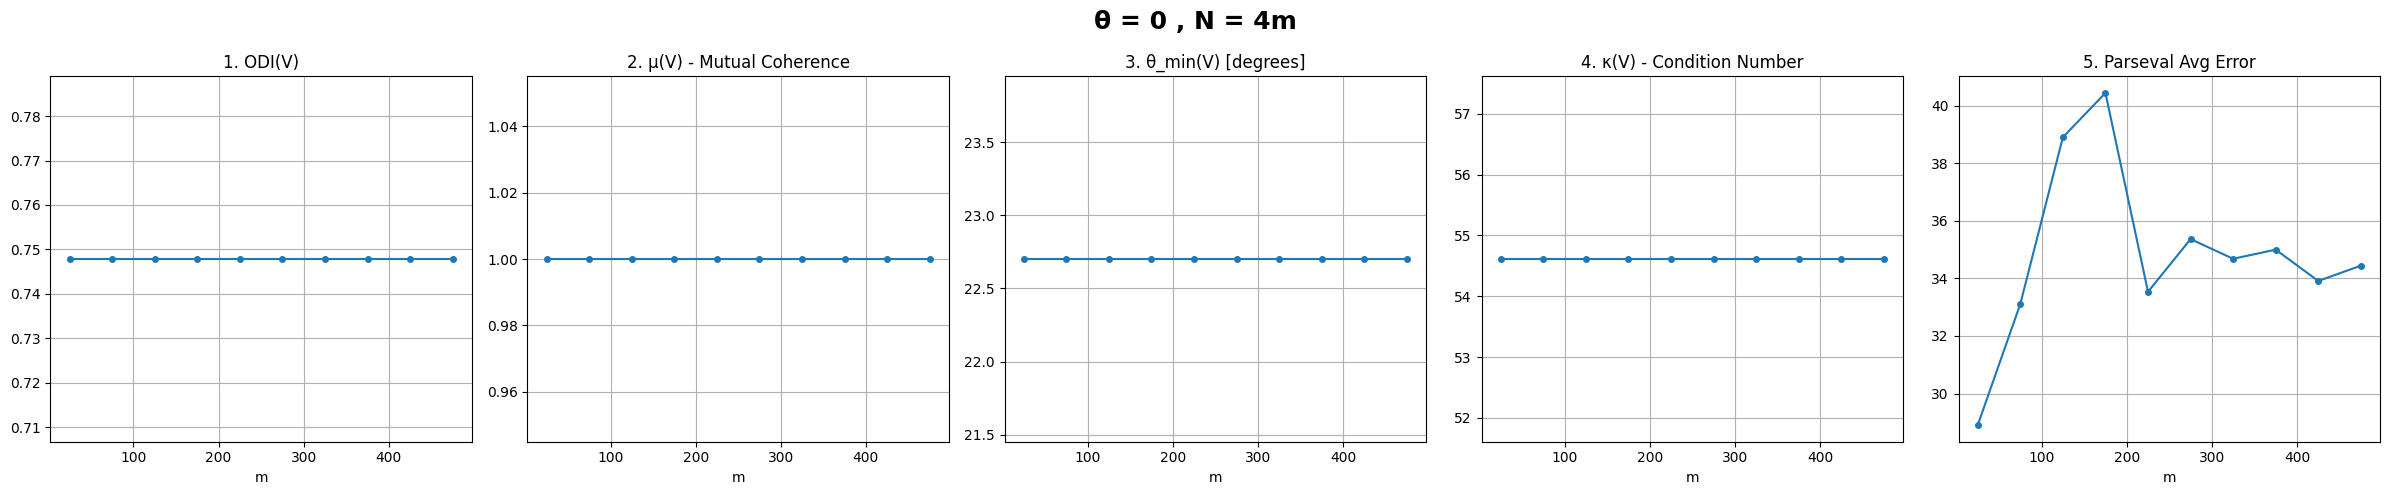

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m

    V = F_vector1

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 0 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


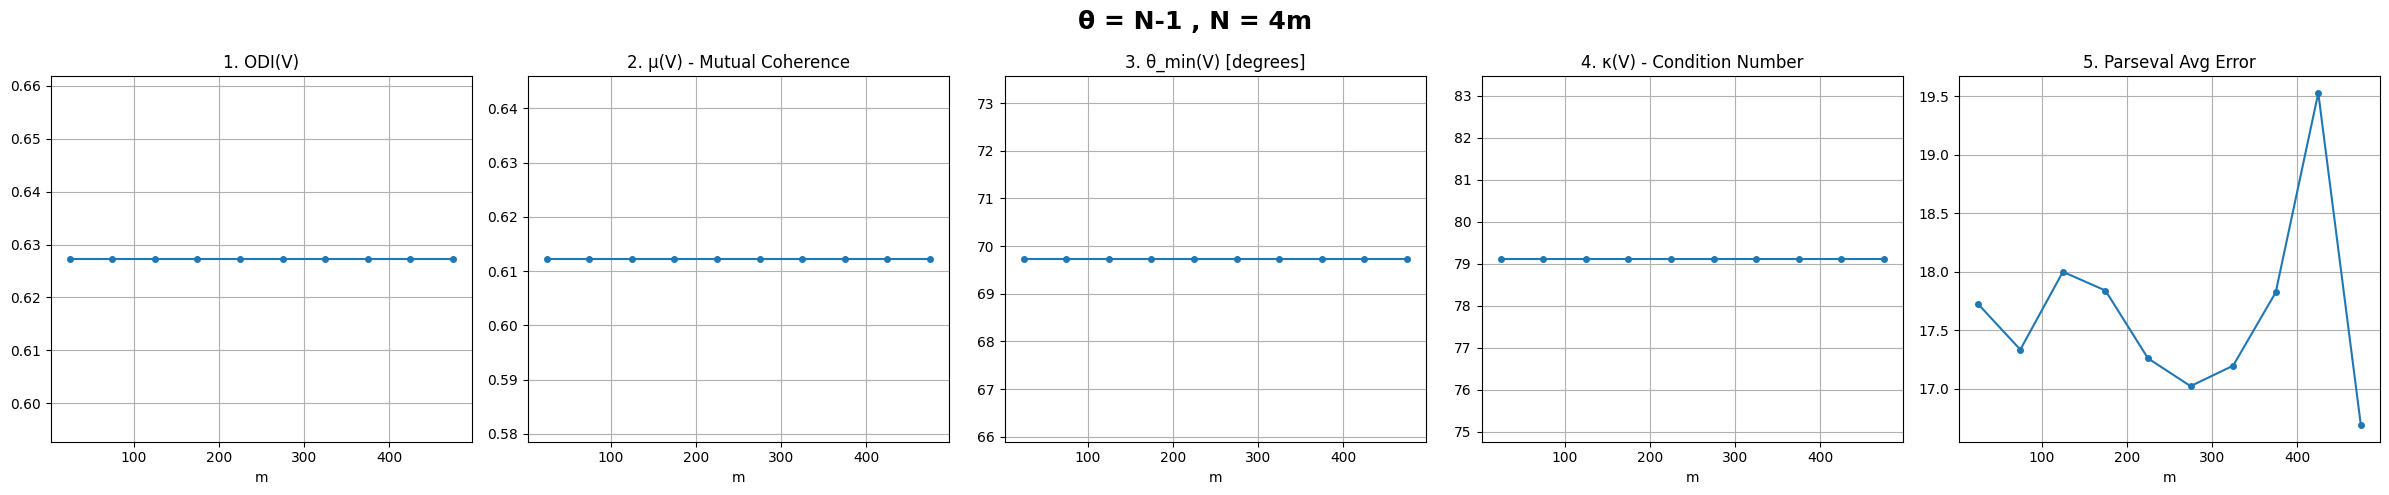

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m

    V = G_c_vector1

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = N-1 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


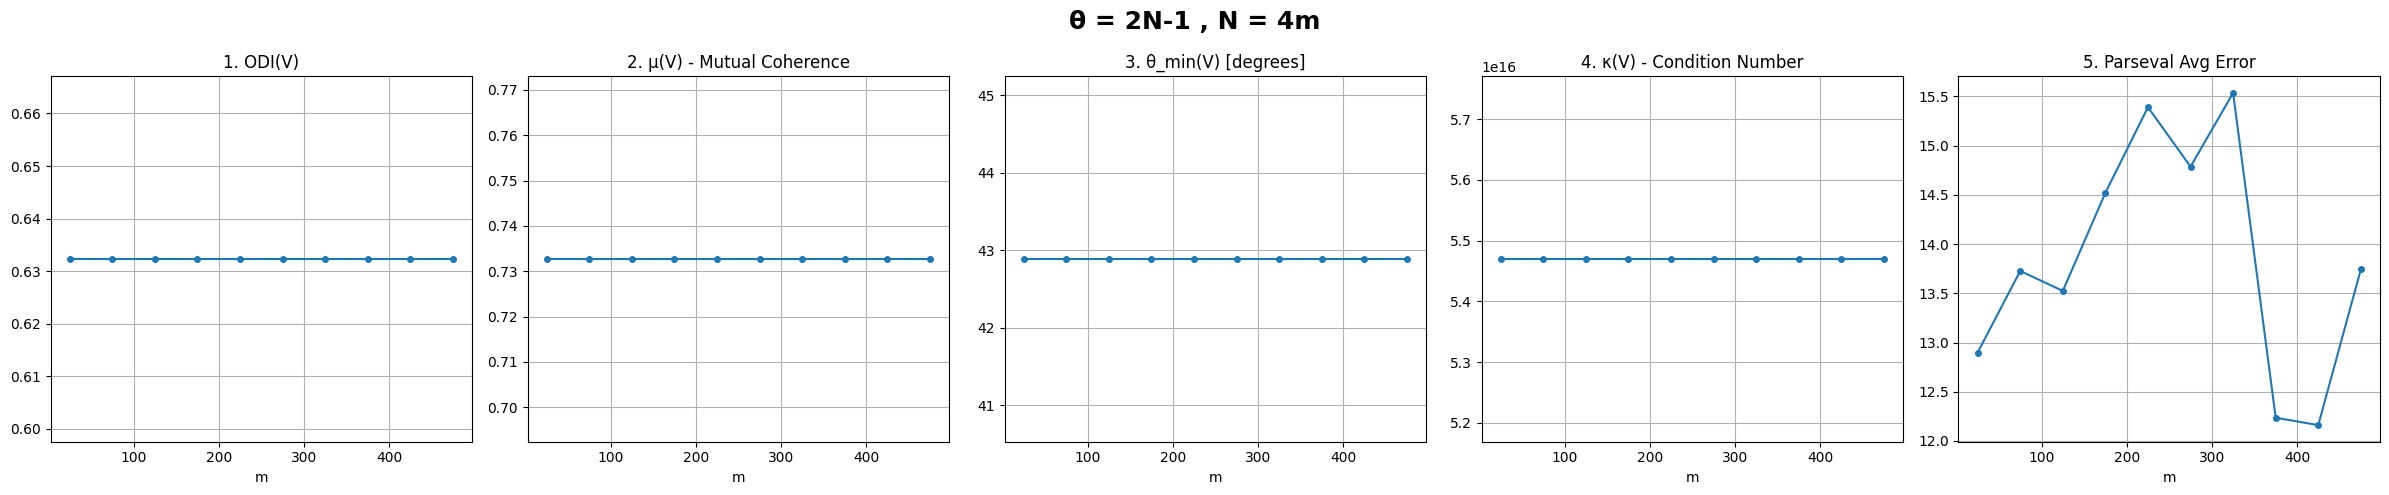

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m

    V = G_vector1

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 2N-1 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


Tale4 : a,b,c,d for $N=4m+1$

In [63]:
import numpy as np

# Parameters
m=3
N = 4*m+1
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)

# Kronecker delta matrices
delta_0 = (k == 0).astype(int)                 # delta_0[k]
delta_l = (k == l).astype(int)                 # delta_l[k]
delta_N_minus_l = (k == (N - l)).astype(int)   # delta_{N-l}[k]

# c_l[k]  matrix
c_l = 1/np.sqrt(N) * np.cos((2 * np.pi / N) * k * l)
s_l = 1/np.sqrt(N) * np.sin((2 * np.pi / N) * k * l)

# Initialize Xc, Yc, Xh, Yh as (5, 5) matrices for compatibility
# === Centered cosine & sine ===
k_centered = k - (N - 1) / 2
l_centered = l - (N - 1) / 2
Xc = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_centered * l_centered)
Yc = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_centered * l_centered)

# === Half-shifted cosine & sine ===
k_half = k + 0.5
l_half = l + 0.5
Xh = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_half * l_half)
Yh = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_half * l_half)
# -----Combined matrix for theta=0 ----#
cplus1 = c_l + delta_0 + delta_l + delta_N_minus_l
cminus1 = c_l - delta_0 - delta_l - delta_N_minus_l
splusi = s_l - delta_l + delta_N_minus_l
sminusi = s_l + delta_l - delta_N_minus_l

# -----Combined matrix for theta=N-1 ----#
Xplus1 = Xc + delta_l - delta_N_minus_l
Xminus1 = Xc - delta_l + delta_N_minus_l
Xplusi = Yc - delta_l - delta_N_minus_l
Xminusi = Yc + delta_l + delta_N_minus_l

# -----Combined matrix for theta=2N-1 ----#
xhplus1 = Xh + delta_l - delta_N_minus_l
xhminus1 = Xh - delta_l + delta_N_minus_l
xhplusi = Yh - delta_l - delta_N_minus_l
xhminusi = Yh + delta_l + delta_N_minus_l


In [64]:
#--theta=0--- F--#
Cplus1part1=cplus1[:,0:m]
Cplus1part2=cplus1[:,2*m][:, np.newaxis]
Cminus1=cminus1[:,0:m]
Splusi=splusi[:,1:m+1]
Sminusi=sminusi[:,1:m+1]
F_vector2=np.hstack([Cplus1part1, Cplus1part2, Cminus1, Splusi, Sminusi])
#----theta=N-1-- G_c---#

Xcplus1part1 = Xplus1[:,m+1:2*m+1]
Xcplus1part2 = Xplus1[:,0][:, np.newaxis]
Xcminus1 = Xminus1[:,m+1:2*m+1]
Xcplusi = Xplusi[:,m+1:2*m+1]
Xcminusi = Xminusi[:,m+1:2*m+1]
G_c_vector2=np.hstack([Xcplus1part1,Xcplus1part2, Xcminus1, Xcplusi, Xcminusi])

#---theta=2N-1 , G----#

Xhplus1=xhplus1[:,0:m]
Xhminus1=xhminus1[:,0:m]
Xhplusi=xhplusi[:,0:m]
Xhminusipart1=xhminusi[:,0:m]
Xhminusipart2=xhminusi[:,2*m][:, np.newaxis]
G_vector2=np.hstack([Xhplus1, Xhminus1, Xhplusi, Xhminusipart1,Xhminusipart2])


#graph
- $N=4m+1$

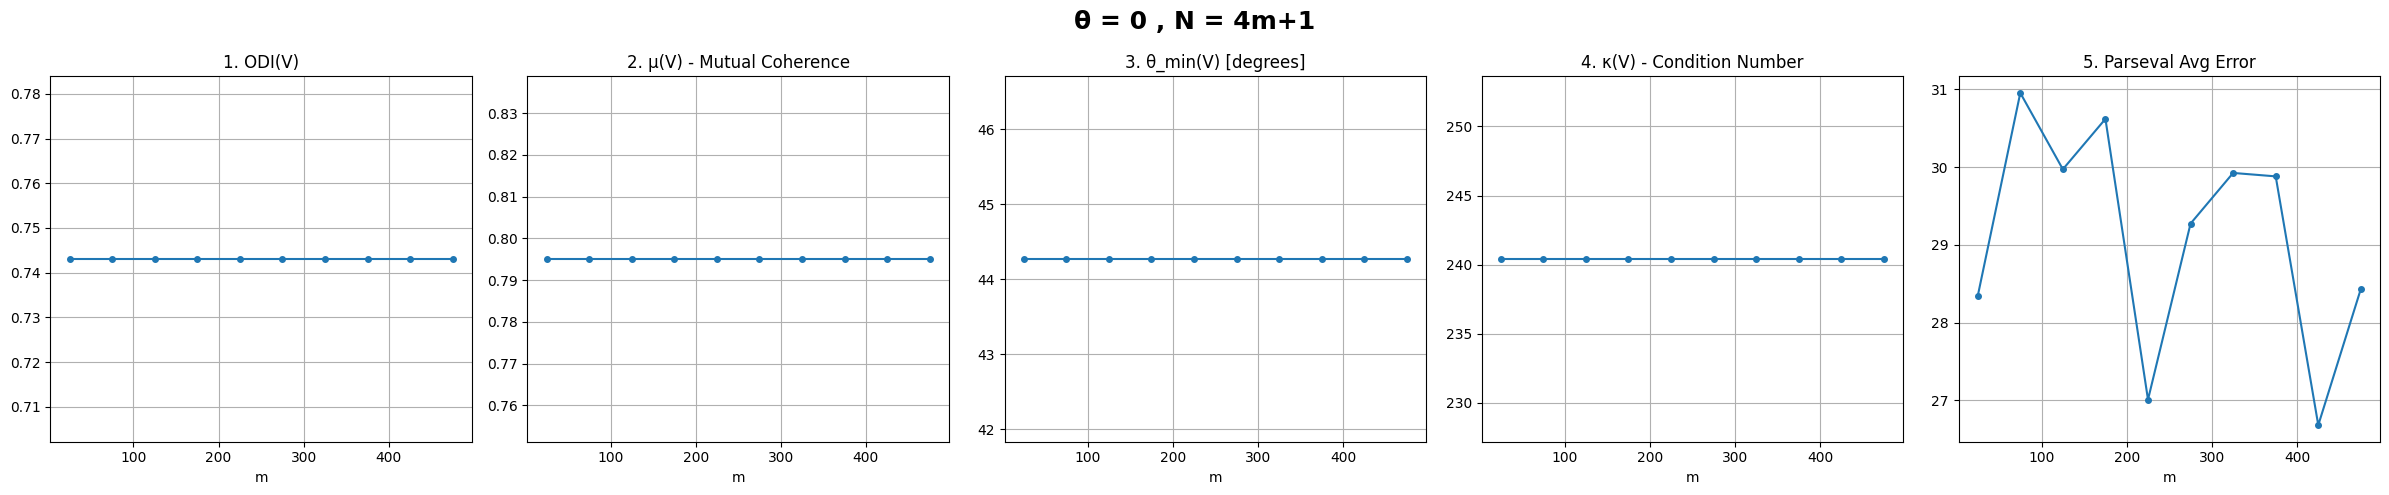

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 1

    V = F_vector2

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 0 , N = 4m+1", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


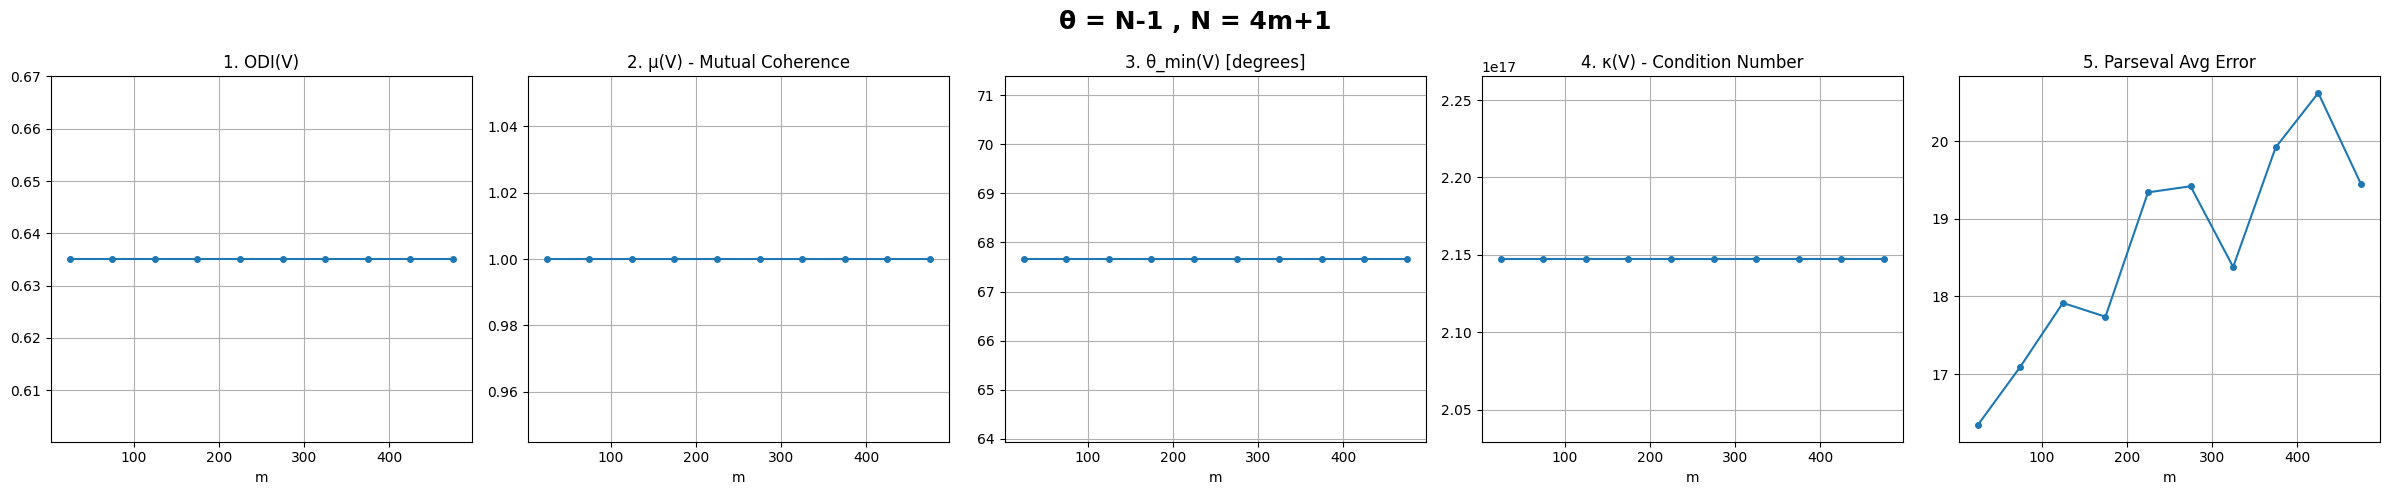

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 1

    V = G_c_vector2

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = N-1 , N = 4m+1", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


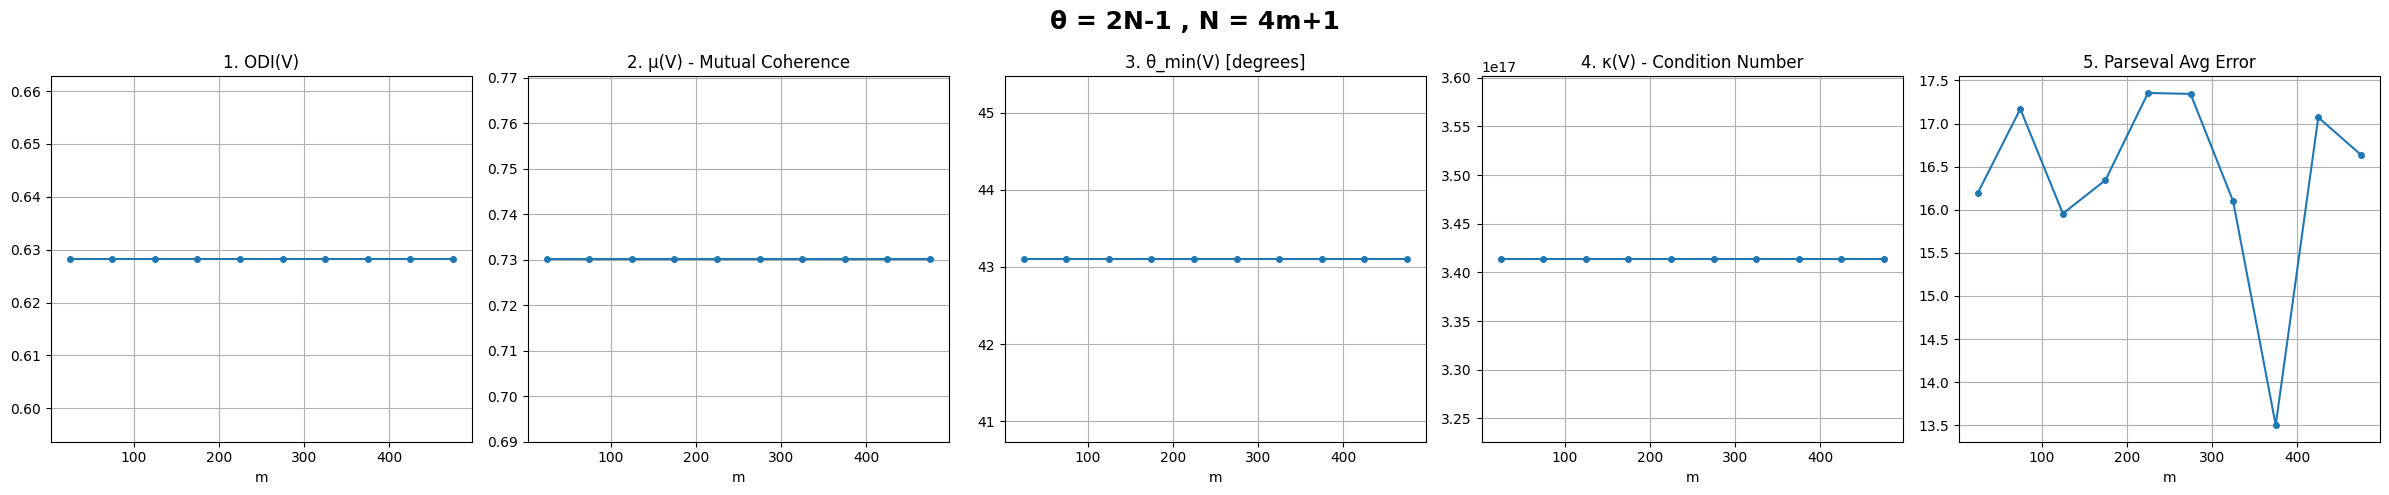

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m+1

    V = G_vector2

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 2N-1 , N = 4m+1", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


#Table4 a,b,c,d for $N=4m+2$

In [69]:
import numpy as np

# Parameters
m=3
N = 4*m+2
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)

# Kronecker delta matrices
delta_0 = (k == 0).astype(int)                 # delta_0[k]
delta_l = (k == l).astype(int)                 # delta_l[k]
delta_N_minus_l = (k == (N - l)).astype(int)   # delta_{N-l}[k]

# c_l[k]  matrix
c_l = 1/np.sqrt(N) * np.cos((2 * np.pi / N) * k * l)
s_l = 1/np.sqrt(N) * np.sin((2 * np.pi / N) * k * l)

# Initialize Xc, Yc, Xh, Yh as (5, 5) matrices for compatibility
# === Centered cosine & sine ===
k_centered = k - (N - 1) / 2
l_centered = l - (N - 1) / 2
Xc = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_centered * l_centered)
Yc = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_centered * l_centered)

# === Half-shifted cosine & sine ===
k_half = k + 0.5
l_half = l + 0.5
Xh = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_half * l_half)
Yh = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_half * l_half)
# -----Combined matrix for theta=0 ----#
cplus1 = c_l + delta_0 + delta_l + delta_N_minus_l
cminus1 = c_l - delta_0 - delta_l - delta_N_minus_l
splusi = s_l - delta_l + delta_N_minus_l
sminusi = s_l + delta_l - delta_N_minus_l

# -----Combined matrix for theta=N-1 ----#
Xplus1 = Xc + delta_l - delta_N_minus_l
Xminus1 = Xc - delta_l + delta_N_minus_l
Xplusi = Yc - delta_l - delta_N_minus_l
Xminusi = Yc + delta_l + delta_N_minus_l

# -----Combined matrix for theta=2N-1 ----#
xhplus1 = Xh + delta_l - delta_N_minus_l
xhminus1 = Xh - delta_l + delta_N_minus_l
xhplusi = Yh - delta_l - delta_N_minus_l
xhminusi = Yh + delta_l + delta_N_minus_l


In [36]:
#--theta=0--- F--#
Cplus1=cplus1[:,0:m+1]
Cminus1=cminus1[:,0:m+1]
Splusi=splusi[:,1:m+1]
Sminusi=sminusi[:,1:m+1]
F_vector3=np.hstack([Cplus1, Cminus1, Splusi, Sminusi])
#----theta=N-1-- G_c---#

Xcplus1part1 = Xplus1[:,m+1:2*m+1]
Xcplus1part2 = Xplus1[:,0][:, np.newaxis]
Xcminus1 = Xminus1[:,m+1:2*m+1]
Xcplusipart1 = Xplusi[:,m+1:2*m+1]
Xcplusipart2 = Xplus1[:,0][:, np.newaxis]
Xcminusi = Xminusi[:,m+1:2*m+1]
G_c_vector3=np.hstack([Xcplus1part1,Xcplus1part2, Xcminus1, Xcplusipart1, Xcplusipart2, Xcminusi])

#---theta=2N-1 , G----#

Xhplus1=xhplus1[:,0:m+1]
Xhminus1=xhminus1[:,0:m+1]
Xhplusi=xhplusi[:,0:m]
Xhminusi=xhminusi[:,0:m]
G_vector3=np.hstack([Xhplus1, Xhminus1, Xhplusi, Xhminusi])


#graph
- $N=4m+2$

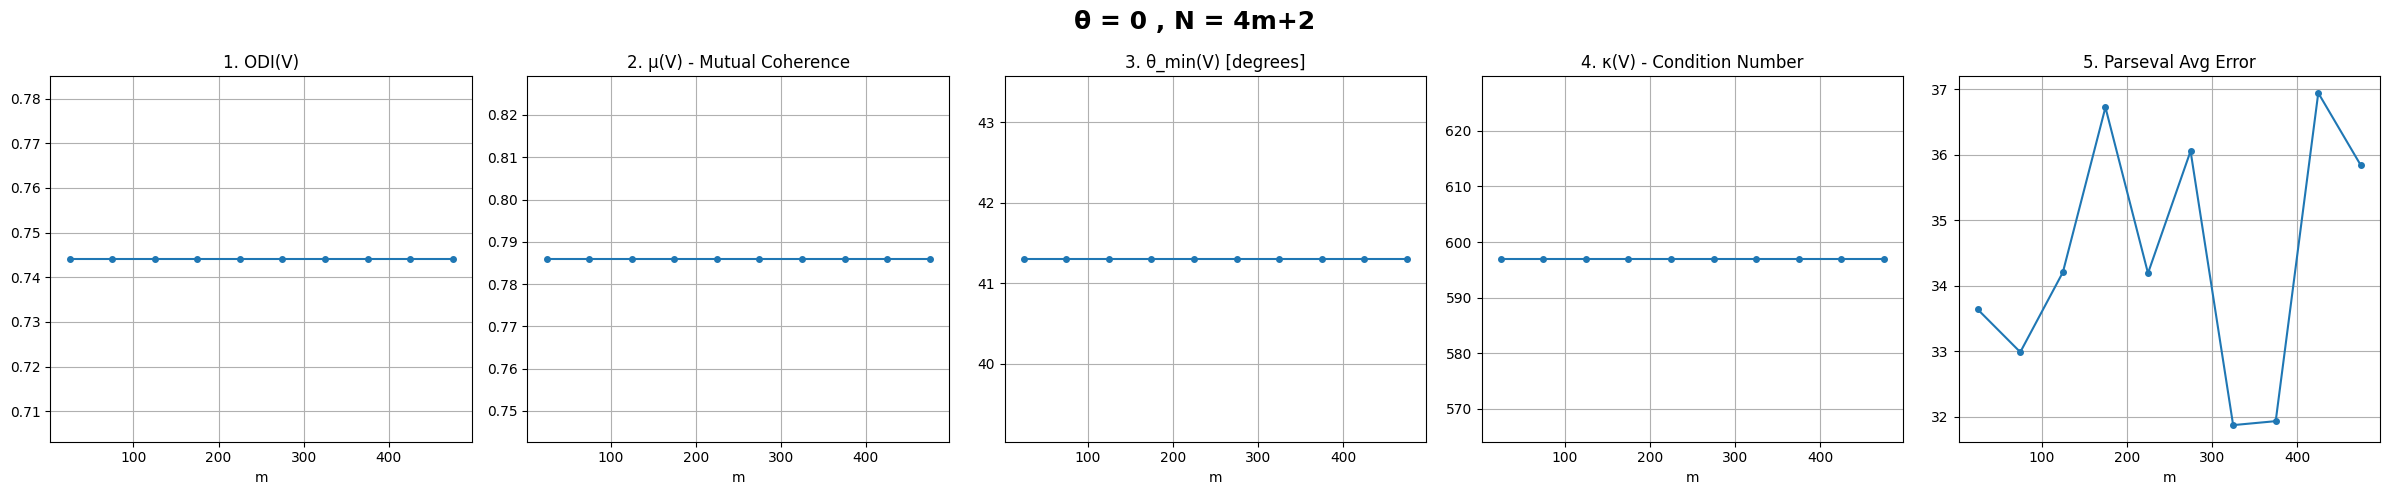

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 2

    V = F_vector3

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 0 , N = 4m+2", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


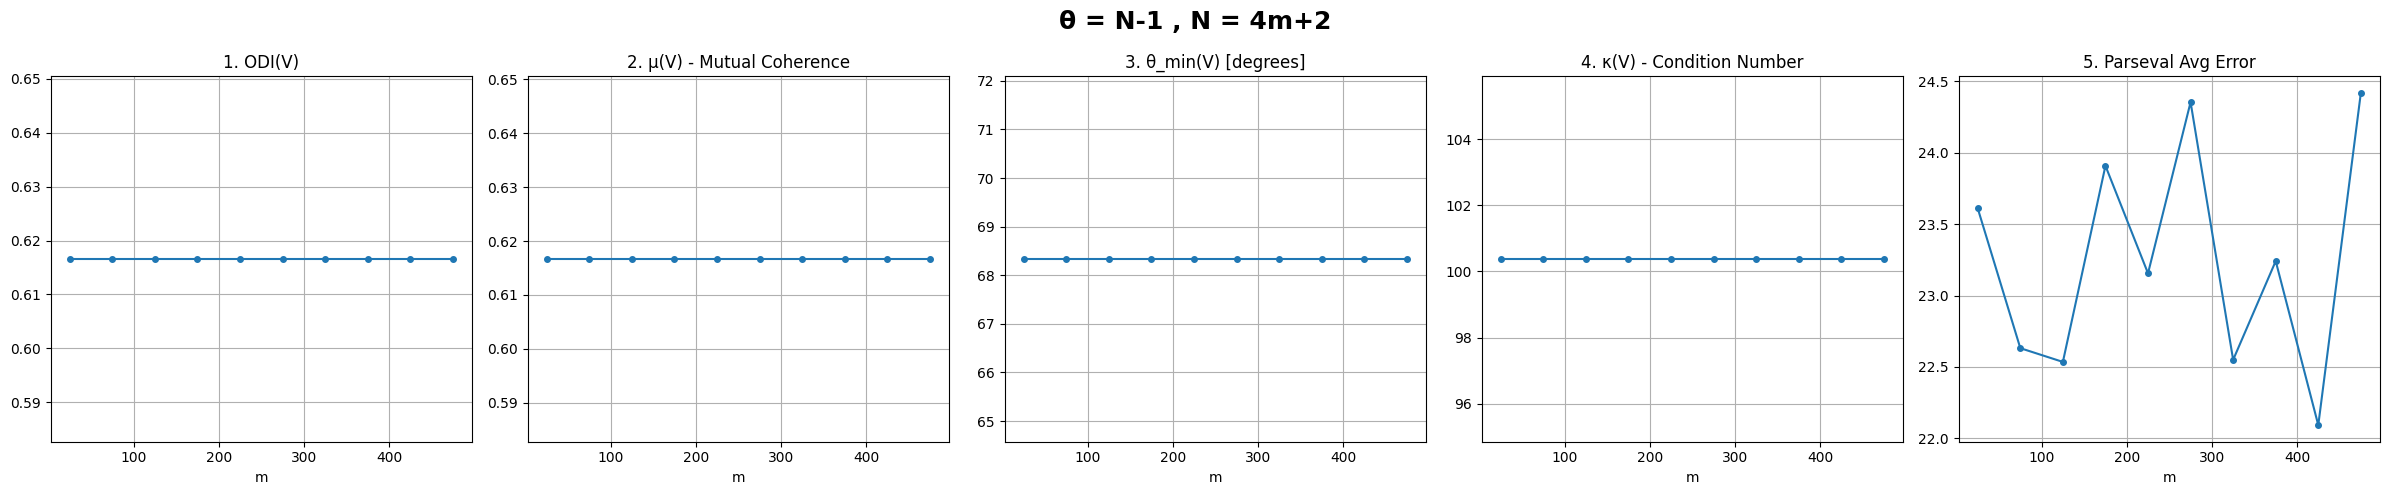

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 2

    V = G_c_vector3
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = N-1 , N = 4m+2", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


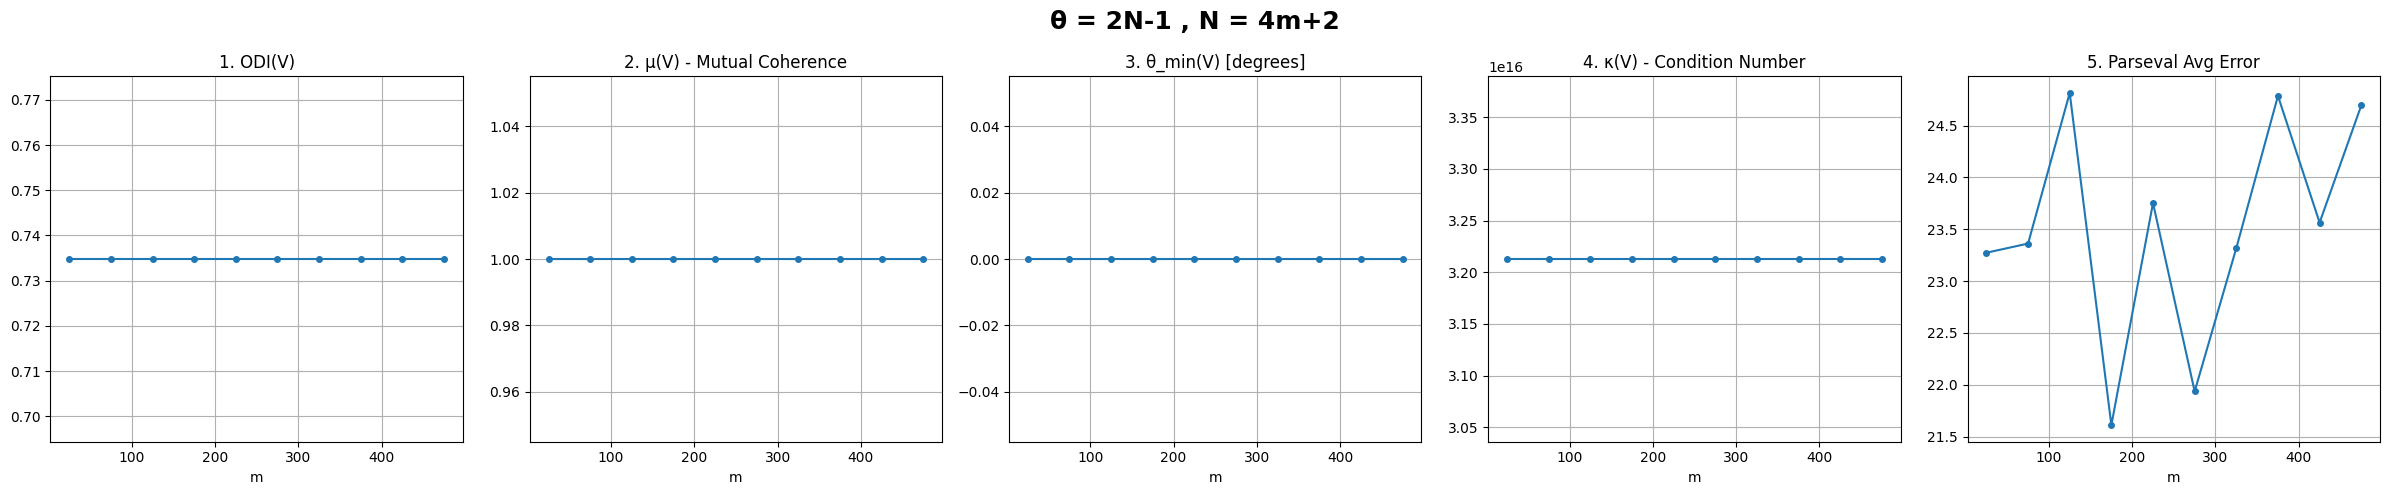

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 2

    V = G_vector3

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 2N-1 , N = 4m+2", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


#Table 4, a,b,c,d for $N=4m+3$

In [75]:
import numpy as np

# Parameters
m=3
N = 4*m+3
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)

# Kronecker delta matrices
delta_0 = (k == 0).astype(int)                 # delta_0[k]
delta_l = (k == l).astype(int)                 # delta_l[k]
delta_N_minus_l = (k == (N - l)).astype(int)   # delta_{N-l}[k]

# c_l[k]  matrix
c_l = 1/np.sqrt(N) * np.cos((2 * np.pi / N) * k * l)
s_l = 1/np.sqrt(N) * np.sin((2 * np.pi / N) * k * l)

# Initialize Xc, Yc, Xh, Yh as (5, 5) matrices for compatibility
# === Centered cosine & sine ===
k_centered = k - (N - 1) / 2
l_centered = l - (N - 1) / 2
Xc = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_centered * l_centered)
Yc = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_centered * l_centered)

# === Half-shifted cosine & sine ===
k_half = k + 0.5
l_half = l + 0.5
Xh = (1 / np.sqrt(N)) * np.cos((2 * np.pi / N) * k_half * l_half)
Yh = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * k_half * l_half)
# -----Combined matrix for theta=0 ----#
cplus1 = c_l + delta_0 + delta_l + delta_N_minus_l
cminus1 = c_l - delta_0 - delta_l - delta_N_minus_l
splusi = s_l - delta_l + delta_N_minus_l
sminusi = s_l + delta_l - delta_N_minus_l

# -----Combined matrix for theta=N-1 ----#
Xplus1 = Xc + delta_l - delta_N_minus_l
Xminus1 = Xc - delta_l + delta_N_minus_l
Xplusi = Yc - delta_l - delta_N_minus_l
Xminusi = Yc + delta_l + delta_N_minus_l

# -----Combined matrix for theta=2N-1 ----#
xhplus1 = Xh + delta_l - delta_N_minus_l
xhminus1 = Xh - delta_l + delta_N_minus_l
xhplusi = Yh - delta_l - delta_N_minus_l
xhminusi = Yh + delta_l + delta_N_minus_l


In [76]:
#--theta=0--- F--#
Cplus1=cplus1[:,0:m+1]
Cminus1=cminus1[:,0:m+1]
Splusi=splusi[:,1:m+1]
Sminusipart1=sminusi[:,1:m+1]
Sminusipart2=sminusi[:,2*m+1][:, np.newaxis]
F_vector4=np.hstack([Cplus1, Cminus1, Splusi, Sminusipart1,Sminusipart2])
#----theta=N-1-- G_c---#

Xcplus1= Xplus1[:,m+1:2*m+2]
Xcminus1 = Xminus1[:,m+1:2*m+2]
Xcplusipart1 = Xplusi[:,m+1:2*m+1]
Xcplusipart2 = Xplus1[:,0][:, np.newaxis]
Xcminusi = Xminusi[:,m+1:2*m+1]
G_c_vector4=np.hstack([Xcplus1, Xcminus1, Xcplusipart1, Xcplusipart2, Xcminusi])

#---theta=2N-1 , G----#

Xhplus1part1=xhplus1[:,0:m]
Xhplus1part2=xhplus1[:,2*m][:, np.newaxis]
Xhminus1=xhminus1[:,0:m]
Xhplusi=xhplusi[:,0:m+1]
Xhminusi=xhminusi[:,0:m+1]
G_vector4=np.hstack([Xhplus1part1, Xhplus1part1, Xhminus1, Xhplusi, Xhminusi])


#graph
-  $N=4m+3$

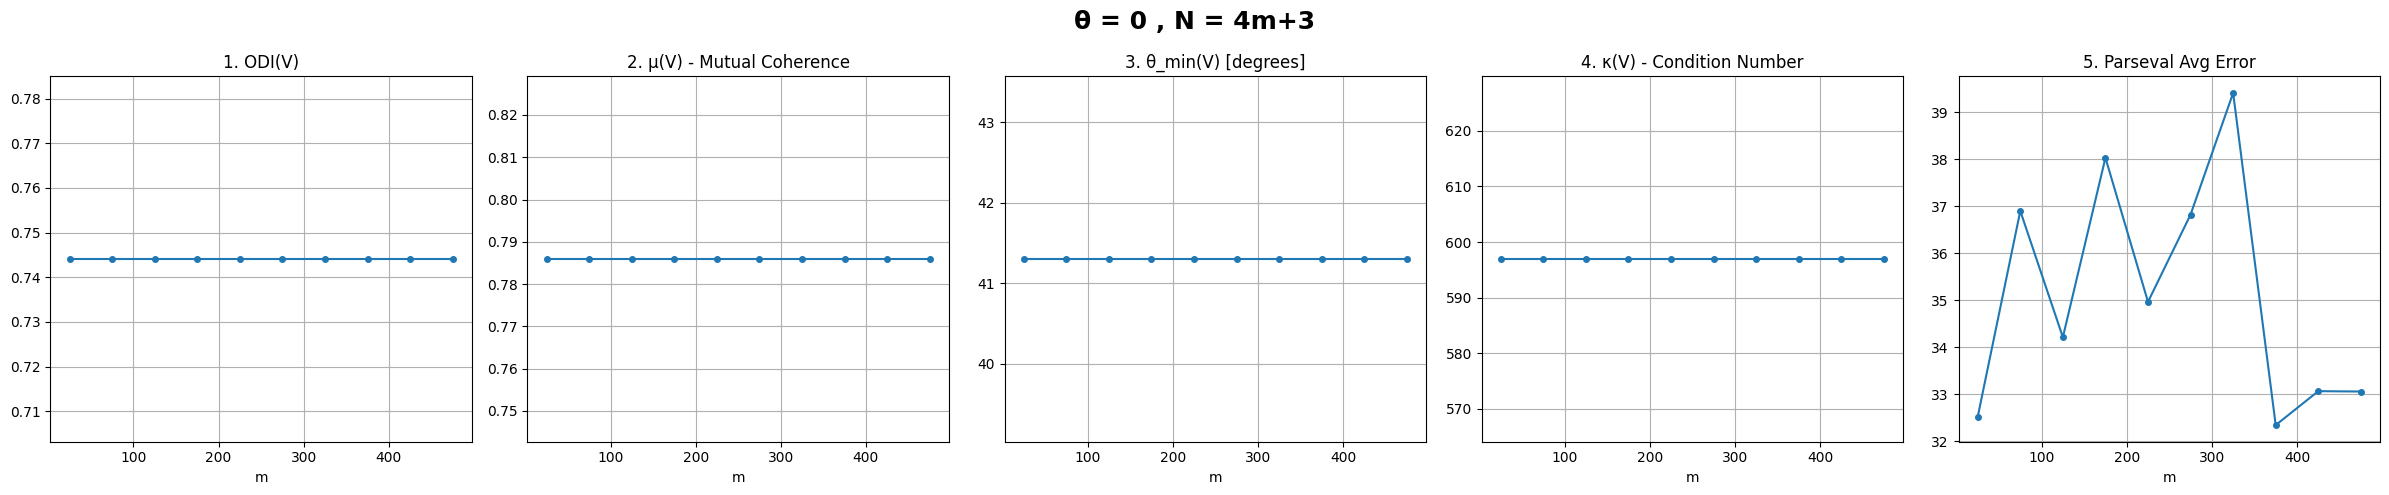

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 3

    V = F_vector4

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 0 , N = 4m+3", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


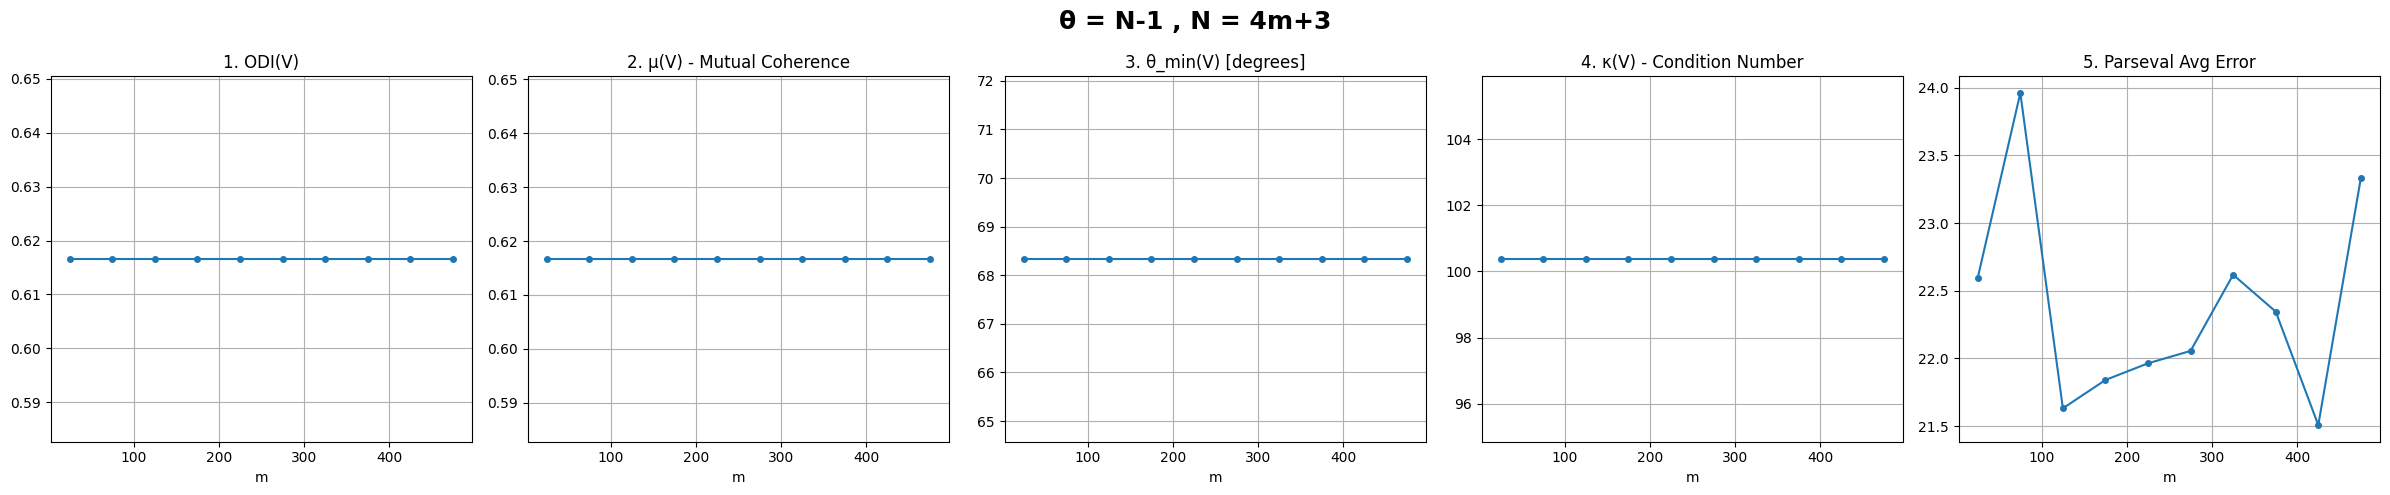

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 3

    V = G_c_vector4

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = N-1 , N = 4m+3", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


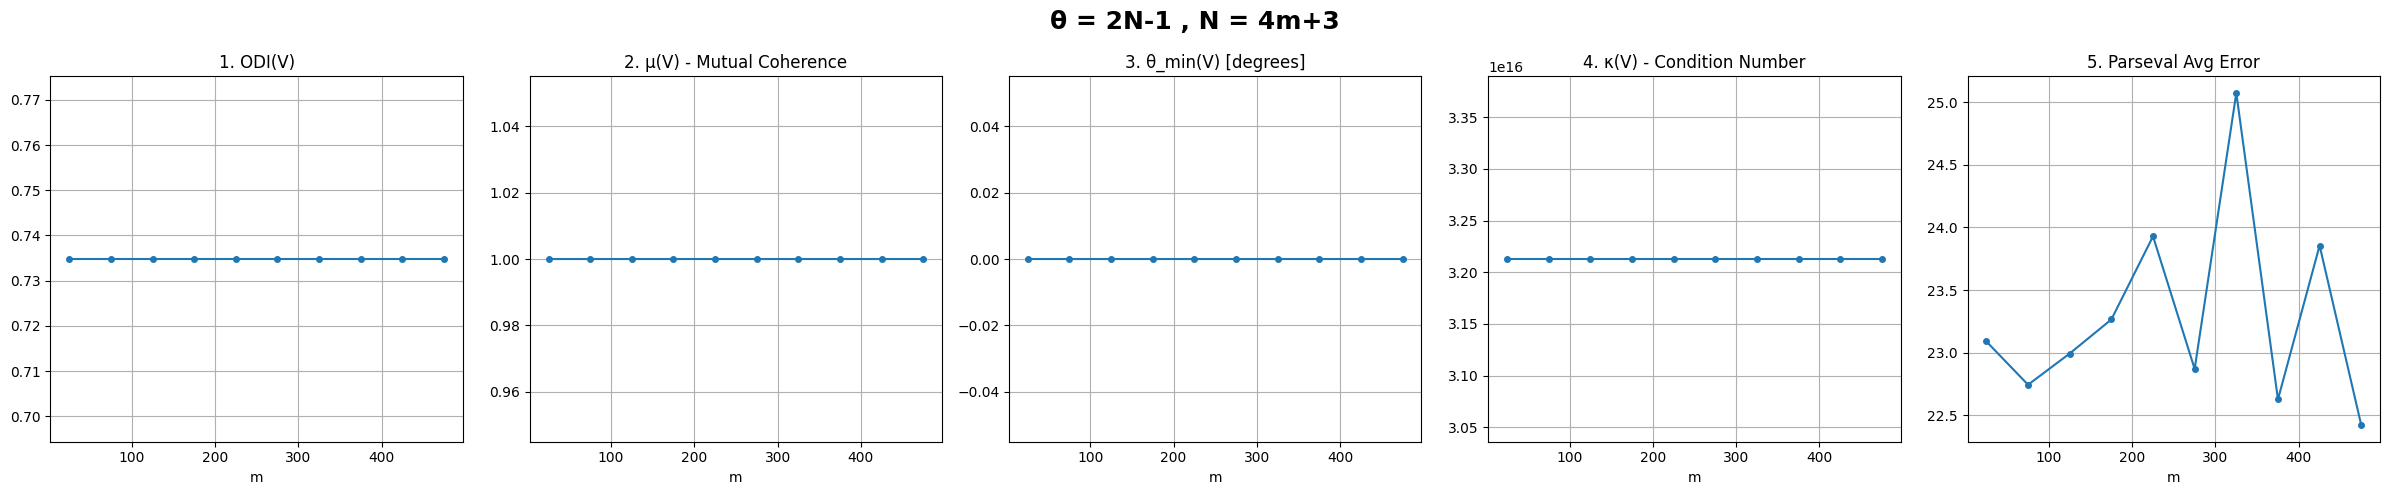

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Define m values
m_values = np.arange(25, 501, 50)

# Initialize metric storage
ODI_vals = []
mu_vals = []
cond_vals = []
theta_min_vals = []
parseval_errors = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

def check_parseval_equality(V, n_samples=100):
    """
    Verifies Parseval equality for basis V using random test vectors.

    Parameters:
    V (numpy.ndarray): Basis matrix (n × k)
    n_samples (int): Number of random test vectors

    Returns:
    tuple: (discrepancies list, average discrepancy)
    """
    n, k = V.shape
    discrepancies = []

    for _ in range(n_samples):
        x = np.random.randn(n)
        left_side = np.sum([np.dot(x, v_i)**2 for v_i in V.T])
        right_side = np.linalg.norm(x)**2
        discrepancies.append(np.abs(left_side - right_side))

    return discrepancies, np.mean(discrepancies)

# === Main Loop ===
for m in m_values:
    N = 4 * m + 3

    V = G_vector4

    # === ODI ===
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)




    # === Mutual Coherence ===
    mu = np.max([
        abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
        for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])
    ])
    mu_vals.append(mu)

    # === Condition Number ===
    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    # === Minimum Angle ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # === Parseval Error with multiple samples ===
    _, avg_error = check_parseval_equality(V, n_samples=100)
    parseval_errors.append(avg_error)

# === Plotting the 5 Metrics ===
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. θ_min(V) [degrees]",
    "4. κ(V) - Condition Number",
    "5. Parseval Avg Error"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals,
    cond_vals,
    parseval_errors
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 2N-1 , N = 4m+3", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


#Table 5
- $C$ , $S$ when $\theta=0$
-  $FrC_c$ ,$FrS_c$ when $\theta=N-1$
-  $FrC$ ,$FrS$ when $\theta=2N-1$

-   Case1 , $N=2m$

In [34]:
import numpy as np

# Parameters
m = 4
N = 2 * m

# =========================
# Original Cosine matrix C
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

d = np.ones(m + 1)
d[0] = 1 / np.sqrt(2)
d[m] = 1 / np.sqrt(2)

D = np.outer(d, d)
C = (1 / np.sqrt(N)) * D * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Original Sine matrix S
# =========================
k_s = np.arange(1, m).reshape(-1, 1)
l_s = np.arange(1, m).reshape(1, -1)
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c
# =========================
k_fr = np.arange(0, m).reshape(-1, 1)
l_fr = np.arange(0, m).reshape(1, -1)

FrC_c = (1 / np.sqrt(N)) * np.cos(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1 / np.sqrt(N)) * np.sin(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))

# =========================
# FrC and FrS
# =========================
FrC = (1 / np.sqrt(N)) * np.cos(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))
FrS = (1 / np.sqrt(N)) * np.sin(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))

# =========================
# Function to check if M^2 = I
# =========================
def check_identity(name, M):
    I = np.eye(M.shape[0])
    if np.allclose(M @ M, 0.25*I, atol=1e-8):
        print(f"✅ {name}^2 = 0.25*I")
    else:
        print(f"❌ {name}^2 ≠ 0.25*I")

# =========================
# Run checks
# =========================
check_identity("C", C)
check_identity("S", S)
check_identity("FrC_c", FrC_c)
check_identity("FrS_c", FrS_c)
check_identity("FrC", FrC)
check_identity("FrS", FrS)


✅ C^2 = 0.25*I
✅ S^2 = 0.25*I
✅ FrC_c^2 = 0.25*I
✅ FrS_c^2 = 0.25*I
✅ FrC^2 = 0.25*I
✅ FrS^2 = 0.25*I


#Table6
- Case 1, $N=2m$

In [53]:
import numpy as np

# Parameters
m = 4
N = 2 * m

# =========================
# Original Cosine matrix C
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

d = np.ones(m + 1)
d[0] = 1 / np.sqrt(2)
d[m] = 1 / np.sqrt(2)

Q = np.outer(d, d)
C = (1 / np.sqrt(N)) * Q * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Original Sine matrix S
# =========================
k_s = np.arange(1, m).reshape(-1, 1)
l_s = np.arange(1, m).reshape(1, -1)
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c
# =========================
k_fr = np.arange(0, m).reshape(-1, 1)
l_fr = np.arange(0, m).reshape(1, -1)

FrC_c = (1 / np.sqrt(N)) * np.cos(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1 / np.sqrt(N)) * np.sin(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))

# =========================
# FrC and FrS
# =========================
FrC = (1/ np.sqrt(N)) * np.cos(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))
FrS = (1 / np.sqrt(N)) * np.sin(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))

# Identity matrices
I_C = np.eye(C.shape[0])
I_S = np.eye(S.shape[0])
I_FrC_c = np.eye(FrC_c.shape[0])
I_FrS_c = np.eye(FrS_c.shape[0])
I_FrC = np.eye(FrC.shape[0])
I_FrS = np.eye(FrS.shape[0])

# Flip matrices
J_C = np.fliplr(I_C)
J_S = np.fliplr(I_S)
J_FrC_c = np.fliplr(I_FrC_c)
J_FrS_c = np.fliplr(I_FrS_c)
J_FrC = np.fliplr(I_FrC)
J_FrS = np.fliplr(I_FrS)

# =========================
# Construct tilde_V matrices for C
# =========================
A_plus = C + 0.5*I_C
A_minus = C - 0.5*I_C

alpha1 = (A_plus[0, :]).reshape(1, -1)
beta1 = (A_plus[-1, :]).reshape(1, -1)
v01 = A_plus[1:-1, :]
tilde_Vcp1 = np.vstack([np.sqrt(2) * alpha1, v01, np.sqrt(2) * beta1, J_C[1:-1, 1:-1] @ v01])

alpha2 = (A_minus[0, :]).reshape(1, -1)
beta2 = (A_minus[-1, :]).reshape(1, -1)
v02 = A_minus[1:-1, :]
tilde_Vcm1 = np.vstack([np.sqrt(2) * alpha2, v02, np.sqrt(2) * beta2, J_C[1:-1, 1:-1] @ v02])

# =========================
# Construct tilde_V matrices for S
# =========================
S_plus = S + 0.5*I_S
S_minus = S - 0.5*I_S

# Middle part for tilde_V
v0_plus = S_plus
v0_minus = S_minus

# Construct tilde_V for S_plus
tilde_V_S_plus = np.vstack([
    np.zeros((1, S_plus.shape[1])),
    v0_plus,
    np.zeros((1, S_plus.shape[1])),
    -(J_S @ v0_plus)
])

# Construct tilde_V for S_minus
tilde_V_S_minus = np.vstack([
    np.zeros((1, S_minus.shape[1])),
    v0_minus,
    np.zeros((1, S_minus.shape[1])),
    -(J_S @ v0_minus)
])

# ===========================================================
# Construct tilde_V matrices for FrC_c
# ==========================================================
D = FrC_c + 0.5*I_FrC_c
E = FrC_c - 0.5*I_FrC_c
# Construct tilde_V for D
tilde_V_D = np.vstack([
    D,
    (J_FrC_c @ D)
])

# Construct tilde_V for E
tilde_V_E = np.vstack([
    E,
    (J_FrC_c @ E)
])

# =========================
# Construct tilde_V matrices for FrS_c
# ==================================================================
M_plus = FrS_c + 0.5*I_FrS_c
M_minus = FrS_c - 0.5*I_FrS_c
# Construct tilde_V for F
tilde_V_M_plus = np.vstack([
    M_plus,
    -(J_FrS_c @ M_plus)
])

# Construct tilde_V for G
tilde_V_N = np.vstack([
    M_minus,
    -(J_FrS_c @ M_minus)
])

# =========================
# Construct tilde_V matrices for FrC
# =========================
H_plus = FrC + 0.5*I_FrC
H_minus = FrC - 0.5*I_FrC
# Construct tilde_V for H_plus
tilde_V_H_plus = np.vstack([
    H_plus,
    -J_FrC @ H_plus
])

# Construct tilde_V for H_minus
tilde_V_H_minus = np.vstack([
    H_minus,
    -J_FrC @ H_minus
])

# =========================
# Construct tilde_V matrices for FrS
# =========================
K_plus = FrS + 0.5*I_FrS
K_minus = FrS - 0.5*I_FrS
# Construct tilde_V for K_plus
tilde_V_K_plus = np.vstack([
    K_plus,
    J_FrS @ K_plus
])

# Construct tilde_V for K_minus
tilde_V_K_minus = np.vstack([
    K_minus,
    J_FrS @ K_minus
])


#Check Table 6 for $N=2m$



In [54]:
import numpy as np

# =========================
# Define DCT_theta and DST_theta
# =========================
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1,1)
    l = np.arange(N).reshape(1,-1)
    return (1/np.sqrt(N)) * np.cos((k - theta/2)*(l - theta/2)*2*np.pi/N)

def DST_theta(N, theta):
    k = np.arange(N).reshape(-1,1)
    l = np.arange(N).reshape(1,-1)
    return (1/np.sqrt(N)) * np.sin((k - theta/2)*(l - theta/2)*2*np.pi/N)

# =========================
# List of tilde_V matrices
# Replace these with the actual matrices you have for N=2*m, m=4
# =========================
tilde_V_list = [
    ("C", tilde_Vcp1, tilde_Vcm1, 2*m),
    ("S", tilde_V_S_plus, tilde_V_S_minus, 2*m),
    ("FrC_c", tilde_V_D, tilde_V_E, 2*m),
    ("FrS_c", tilde_V_M_plus, tilde_V_N, 2*m),
    ("FrC", tilde_V_H_plus, tilde_V_H_minus, 2*m),
    ("FrS", tilde_V_K_plus, tilde_V_K_minus, 2*m)
]

# =========================
# Check each column separately for ±1 eigenvector
# =========================
tolerance = 1e-12  # stricter tolerance to avoid numerical ambiguity

for name, V_plus, V_minus, N_val in tilde_V_list:

    # Determine theta and function
    if name in ["C", "S"]:
        theta = 0
        mat_func = DCT_theta if name=="C" else DST_theta
    elif name in ["FrC_c", "FrS_c"]:
        theta = N_val - 1
        mat_func = DCT_theta if "C" in name else DST_theta
    else:  # FrC, FrS
        theta = 2*N_val - 1
        mat_func = DCT_theta if "C" in name else DST_theta

    # Generate DCT/DST matrix
    F = mat_func(N_val, theta)

    # Helper function to check eigenvalue ±1
    def check_eigenvector(v):
        eig_val = F @ v
        if np.allclose(eig_val, v, atol=tolerance):
            return "✅(+1)"
        elif np.allclose(eig_val, -v, atol=tolerance):
            return "✅(-1)"
        else:
            return "❌"

    # Check V_plus
    res_plus = [check_eigenvector(V_plus[:, j]) for j in range(V_plus.shape[1])]

    # Check V_minus
    res_minus = [check_eigenvector(V_minus[:, j]) for j in range(V_minus.shape[1])]

    # Print results
    print(f"\n{name}:")
    print("  V_plus  →", res_plus)
    print("  V_minus →", res_minus)



C:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

S:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)']

FrC_c:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrS_c:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrC:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrS:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']


#Table 8 , $N=2m$, theorem 2.3

In [57]:
import numpy as np

# Parameters
m = 4
N = 2 * m
#=======Initialize matrix=========theta=0=======
C0 = np.zeros((N, N))
S0 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        C0[k, l] = (1 / np.sqrt(N)) * np.cos((k) * (l) * (2 * np.pi / N))
for k in range(N):
    for l in range(N):
        S0[k, l] = (1 / np.sqrt(N)) * np.sin((k) * (l) * (2 * np.pi / N))
#=======Initialize matrix=========theta=N-1=======
FrC_Nm1 = np.zeros((N, N))
FrS_Nm1 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        FrC_Nm1[k, l] = (1/np.sqrt(N)) * np.cos((k - (N-1)/2)*(l - (N-1)/2)*2*np.pi/N)
for k in range(N):
    for l in range(N):
        FrS_Nm1[k, l] = (1/np.sqrt(N)) * np.sin((k - (N-1)/2)*(l - (N-1)/2)*2*np.pi/N)

#=======Initialize matrix=========theta=2N-1=======
FrC_Nm2 = np.zeros((N, N))
FrS_Nm2 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        FrC_Nm2[k, l] = (1/np.sqrt(N)) * np.cos((k + 1/2)*(l + 1/2)*2*np.pi/N)
for k in range(N):
    for l in range(N):
        FrS_Nm2[k, l] = (1/np.sqrt(N)) * np.sin((k + 1/2)*(l + 1/2)*2*np.pi/N)


# =========================
# Original Cosine matrix C
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

d = np.ones(m + 1)
d[0] = 1 / np.sqrt(2)
d[m] = 1 / np.sqrt(2)

Q = np.outer(d, d)
C = (1 / np.sqrt(N)) * Q * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Original Sine matrix S
# =========================
k_s = np.arange(1, m ).reshape(-1, 1)  # Changed to include m
l_s = np.arange(1, m ).reshape(1, -1)  # Changed to include m
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c
# =========================
k_fr = np.arange(0, m).reshape(-1, 1)
l_fr = np.arange(0, m).reshape(1, -1)

FrC_c = ( 1/ np.sqrt(N)) * np.cos(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1/ np.sqrt(N)) * np.sin(((k_fr - (N - 1) / 2) * (l_fr - (N - 1) / 2)) * (2 * np.pi / N))

#====================== FrC and FrS====================
# =====================================================
FrC = (1 / np.sqrt(N)) * np.cos(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))
FrS = (1/ np.sqrt(N)) * np.sin(((k_fr + 0.5) * (l_fr + 0.5)) * (2 * np.pi / N))

#=======================block matrix===================#
#=====================================================
Cstar = C[1:-1, 1:-1]
val = 1 / np.sqrt(N)


#================= Step 0: identity and flip matrices============
#==============================================================
I = np.eye(m-1)
J = np.fliplr(np.eye(m-1, dtype=int))

# Step 2: Build recon_C and recon_S
recon_C = np.zeros((N, N))
recon_S = np.zeros((N, N))
recon_FrC_c = np.zeros((N, N))
recon_FrS_c = np.zeros((N, N))
recon_FrC = np.zeros((N, N))
recon_FrS = np.zeros((N, N))

# ===============Insert block recon_C============#
#=================================================
recon_C[0, :] = val
recon_C[:, 0] = val
recon_C[m, :] = val * (-1) ** np.arange(N)
recon_C[:, m] = val * (-1) ** np.arange(N)
recon_C[1:m, 1:m] = Cstar
recon_C[1:m, m+1:2*m] = Cstar @ J
recon_C[m+1:2*m, 1:m] = J @ Cstar
recon_C[m+1:2*m, m+1:2*m] = J @ Cstar @ J
difference = recon_C - C0
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_C and C0:", max_diff)

if np.allclose(recon_C, C0, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")
#=========== Insert block recon_S===========#
#=============================================
recon_S[1:m, 1:m] = S
recon_S[1:m, m+1:2*m] = -S @ J
recon_S[m+1:2*m, 1:m] = -J @ S
recon_S[m+1:2*m, m+1:2*m] = J @ S @ J

#=========== Insert block recon_FrC_c===========#
#=============================================

I = np.eye(m)
J = np.fliplr(np.eye(m, dtype=int))

recon_FrC_c[0:m,0:m]=FrC_c
recon_FrC_c[0:m,m:2*m]=FrC_c@J
recon_FrC_c[m:2*m,0:m]=J@FrC_c
recon_FrC_c[m:2*m,m:2*m]=J@FrC_c@J
#=========== Insert block recon_FrS_c===========#
#=============================================
recon_FrS_c[0:m,0:m]=FrS_c
recon_FrS_c[0:m,m:2*m]=-FrS_c@J
recon_FrS_c[m:2*m,0:m]=-J@FrS_c
recon_FrS_c[m:2*m,m:2*m]=J@FrS_c@J

#=========== Insert block recon_FrC===========#
#=============================================
recon_FrC[0:m,0:m]=FrC
recon_FrC[0:m,m:2*m]=-FrC@J
recon_FrC[m:2*m,0:m]=-J@FrC
recon_FrC[m:2*m,m:2*m]=J@FrC@J

#=========== Insert block recon_FrS===========#
#=============================================
recon_FrS[0:m,0:m]=FrS
recon_FrS[0:m,m:2*m]=FrS@J
recon_FrS[m:2*m,0:m]=J@FrS
recon_FrS[m:2*m,m:2*m]=J@FrS@J

#=============Check difference with original C0 and S0============
#=================================================================



difference = recon_S - S0
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_S and S0:", max_diff)

if np.allclose(recon_S, S0, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrC_c - FrC_Nm1
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrC_c and FrC_Nm1:", max_diff)

if np.allclose(recon_FrC_c, FrC_Nm1, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")


difference = recon_FrS_c - FrS_Nm1
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrS_c and FrS_Nm1:", max_diff)

if np.allclose(recon_FrS_c, FrS_Nm1, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrC - FrC_Nm2
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrC and FrC_Nm2:", max_diff)

if np.allclose(recon_FrC, FrC_Nm2, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrS - FrS_Nm2
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrS and FrS_Nm2:", max_diff)

if np.allclose(recon_FrS, FrS_Nm2, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")


Maximum absolute difference between recon_C and C0: 9.992007221626409e-16
All entries match ✅

Maximum absolute difference between recon_S and S0: 9.992007221626409e-16
All entries match ✅

Maximum absolute difference between recon_FrC_c and FrC_Nm1: 0.0
All entries match ✅

Maximum absolute difference between recon_FrS_c and FrS_Nm1: 0.0
All entries match ✅

Maximum absolute difference between recon_FrC and FrC_Nm2: 1.3322676295501878e-15
All entries match ✅

Maximum absolute difference between recon_FrS and FrS_Nm2: 1.0269562977782698e-15
All entries match ✅


#Table5
-   Case2 , $N=2m+1$

In [59]:
import numpy as np

# Parameters
m = 4
N = 2 * m + 1

# =========================
# Matrix C (with b_k)
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

b = np.ones(m + 1)
b[0] = 1 / np.sqrt(2)

B = np.outer(b, b)
C = (1 / np.sqrt(N)) * B * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Matrix S
# =========================
k_s = np.arange(1, m + 1).reshape(-1, 1)
l_s = np.arange(1, m + 1).reshape(1, -1)
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c (with a_k)
# =========================
k_frc = np.arange(0, m + 1).reshape(-1, 1)
l_frc = np.arange(0, m + 1).reshape(1, -1)

k_frs = np.arange(0, m ).reshape(-1, 1)
l_frs = np.arange(0, m ).reshape(1, -1)

a = np.ones(m + 1)
a[m] = 1 / np.sqrt(2)

A = np.outer(a, a)

FrC_c = (1 / np.sqrt(N)) * A * np.cos(((k_frc - (N - 1) / 2) * (l_frc - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1 / np.sqrt(N)) * np.sin(((k_frs - (N - 1) / 2) * (l_frs - (N - 1) / 2)) * (2 * np.pi / N))

# =========================
# FrC and FrS
# =========================
k_fc = np.arange(0, m).reshape(-1, 1)
l_fc = np.arange(0, m ).reshape(1, -1)

k_fs = np.arange(0, m+1 ).reshape(-1, 1)
l_fs = np.arange(0, m+1).reshape(1, -1)

FrC = (1 / np.sqrt(N)) * np.cos(((k_fc + 0.5) * (l_fc + 0.5)) * (2 * np.pi / N))
FrS = (1 / np.sqrt(N)) * A * np.sin(((k_fs + 0.5) * (l_fs + 0.5)) * (2 * np.pi / N))

# =========================
# Check function
# =========================
def check_identity(name, M):
    I = np.eye(M.shape[0])
    if np.allclose(M @ M, 0.25*I, atol=1e-8):
        print(f"✅ {name}^2 = 0.25*I")
    else:
        print(f"❌ {name}^2 ≠0.25*I")

# =========================
# Run checks
# =========================
check_identity("C", C)
check_identity("S", S)
check_identity("FrC_c", FrC_c)
check_identity("FrS_c", FrS_c)
check_identity("FrC", FrC)
check_identity("FrS", FrS)


✅ C^2 = 0.25*I
✅ S^2 = 0.25*I
✅ FrC_c^2 = 0.25*I
✅ FrS_c^2 = 0.25*I
✅ FrC^2 = 0.25*I
✅ FrS^2 = 0.25*I


#Table6

-  case1 for N=2m+1

In [60]:
import numpy as np

# Parameters
m = 4
N = 2 * m + 1

# =========================
# Matrix C (with b_k)
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

b = np.ones(m + 1)
b[0] = 1 / np.sqrt(2)

B = np.outer(b, b)
C = (1 / np.sqrt(N)) * B * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Matrix S
# =========================
k_s = np.arange(1, m + 1).reshape(-1, 1)
l_s = np.arange(1, m + 1).reshape(1, -1)
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c (with a_k)
# =========================
k_frc = np.arange(0, m + 1).reshape(-1, 1)
l_frc = np.arange(0, m + 1).reshape(1, -1)

k_frs = np.arange(0, m).reshape(-1, 1)
l_frs = np.arange(0, m).reshape(1, -1)

a = np.ones(m + 1)
a[m] = 1 / np.sqrt(2)

A = np.outer(a, a)

FrC_c = (1 / np.sqrt(N)) * A * np.cos(((k_frc - (N - 1) / 2) * (l_frc - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1 / np.sqrt(N)) * np.sin(((k_frs - (N - 1) / 2) * (l_frs - (N - 1) / 2)) * (2 * np.pi / N))

# =========================
# FrC and FrS
# =========================
k_fc = np.arange(0, m).reshape(-1, 1)
l_fc = np.arange(0, m).reshape(1, -1)

k_fs = np.arange(0, m + 1).reshape(-1, 1)
l_fs = np.arange(0, m + 1).reshape(1, -1)

FrC = (1 / np.sqrt(N)) * np.cos(((k_fc + 0.5) * (l_fc + 0.5)) * (2 * np.pi / N))
FrS = (1 / np.sqrt(N)) * A * np.sin(((k_fs + 0.5) * (l_fs + 0.5)) * (2 * np.pi / N))

# Identity matrices
I_C = np.eye(C.shape[0])
I_S = np.eye(S.shape[0])
I_FrC_c = np.eye(FrC_c.shape[0])
I_FrS_c = np.eye(FrS_c.shape[0])
I_FrC = np.eye(FrC.shape[0])
I_FrS = np.eye(FrS.shape[0])

# Flip matrices
J_C = np.fliplr(I_C)
J_S = np.fliplr(I_S)
J_FrC_c = np.fliplr(I_FrC_c)
J_FrS_c = np.fliplr(I_FrS_c)
J_FrC = np.fliplr(I_FrC)
J_FrS = np.fliplr(I_FrS)

# =========================
# Construct tilde_V matrices for C
# =========================
C_plus = C + 0.5*I_C
C_minus = C - 0.5*I_C

gamma_plus = C_plus[0, :].reshape(1, -1)
gamma_minus = C_minus[0, :].reshape(1, -1)

v0_plus = C_plus[1:, :]
v0_minus = C_minus[1:, :]

J_v0_C = np.fliplr(np.eye(v0_plus.shape[0]))

tilde_V_C_plus = np.vstack([
    np.sqrt(2) * gamma_plus,
    v0_plus,
    J_v0_C @ v0_plus
])

tilde_V_C_minus = np.vstack([
    np.sqrt(2) * gamma_minus,
    v0_minus,
    J_v0_C @ v0_minus
])

# =========================
# Construct tilde_V matrices for S
# =========================
S_plus = S + 0.5*I_S
S_minus = S - 0.5*I_S

tilde_V_S_plus = np.vstack([
    np.zeros((1, S_plus.shape[1])),
    S_plus,
    -J_S @ S_plus
])

tilde_V_S_minus = np.vstack([
    np.zeros((1, S_minus.shape[1])),
    S_minus,
    -J_S @ S_minus
])

# ===========================================================
# Construct tilde_V matrices for FrC_c
# ===========================================================
D_plus = FrC_c + 0.5*I_FrC_c
D_minus = FrC_c - 0.5*I_FrC_c

v0_D_plus = D_plus[:-1, :]
gamma1 = D_plus[-1, :].reshape(1, -1)
J_v0_D = np.fliplr(np.eye(v0_D_plus.shape[0]))  # corrected flip
tilde_V_D_plus = np.vstack([
    v0_D_plus,
    np.sqrt(2) * gamma1,
    J_v0_D @ v0_D_plus
])

v0_D_minus = D_minus[:-1, :]
gamma2 = D_minus[-1, :].reshape(1, -1)
J_v0_D = np.fliplr(np.eye(v0_D_minus.shape[0]))
tilde_V_D_minus = np.vstack([
    v0_D_minus,
    np.sqrt(2) * gamma2,
    J_v0_D @ v0_D_minus
])


# =========================
# Construct tilde_V matrices for FrS_c
# =========================
M_plus = FrS_c + 0.5*I_FrS_c
M_minus = FrS_c - 0.5*I_FrS_c

zero_row_plus = np.zeros((1, M_plus.shape[1]))
tilde_V_M_plus = np.vstack([
    M_plus,
    zero_row_plus,
    -J_FrS_c @ M_plus
])

zero_row_minus = np.zeros((1, M_minus.shape[1]))
tilde_V_M_minus = np.vstack([
    M_minus,
    zero_row_minus,
    -J_FrS_c @ M_minus
])

# =========================
# Construct tilde_V matrices for FrC
# =========================
H_plus = FrC + 0.5*I_FrC
H_minus = FrC - 0.5*I_FrC

tilde_V_H_plus = np.vstack([
    H_plus,
    np.zeros((1, H_plus.shape[1])),
    -J_FrC @ H_plus
])

tilde_V_H_minus = np.vstack([
    H_minus,
    np.zeros((1, H_minus.shape[1])),
    -J_FrC @ H_minus
])

# =========================
# Construct tilde_V matrices for FrS
# =========================
K_plus = FrS + 0.5*I_FrS
K_minus = FrS - 0.5*I_FrS

# --- K_plus ---
v0_K_plus = K_plus[:-1, :]
gamma3_plus = K_plus[-1, :].reshape(1, -1)
J_v0_K = np.fliplr(np.eye(v0_K_plus.shape[0]))

tilde_V_K_plus = np.vstack([
    v0_K_plus,
    np.sqrt(2) * gamma3_plus,
    J_v0_K @ v0_K_plus
])

# --- K_minus ---
v0_K_minus = K_minus[:-1, :]
gamma3_minus = K_minus[-1, :].reshape(1, -1)
J_v0_K = np.fliplr(np.eye(v0_K_minus.shape[0]))

tilde_V_K_minus = np.vstack([
    v0_K_minus,
    np.sqrt(2) * gamma3_minus,
    J_v0_K @ v0_K_minus
])


#Check Table 6 for $N=2m+1$


In [61]:
import numpy as np

# =========================
# Define DCT_theta and DST_theta
# =========================
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * np.cos((k - theta/2) * (l - theta/2) * 2*np.pi/N)

def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * np.sin((k - theta/2) * (l - theta/2) * 2*np.pi/N)

# =========================
# List of all tilde_V matrices
# N_val is set to match actual row dimension of tilde_V
# =========================
tilde_V_list = [
    ("C", tilde_V_C_plus, tilde_V_C_minus, tilde_V_C_plus.shape[0]),
    ("S", tilde_V_S_plus, tilde_V_S_minus, tilde_V_S_plus.shape[0]),
    ("FrC_c", tilde_V_D_plus, tilde_V_D_minus, tilde_V_D_plus.shape[0]),
    ("FrS_c", tilde_V_M_plus, tilde_V_M_minus, tilde_V_M_plus.shape[0]),
    ("FrC", tilde_V_H_plus, tilde_V_H_minus, tilde_V_H_plus.shape[0]),
    ("FrS", tilde_V_K_plus, tilde_V_K_minus, tilde_V_K_plus.shape[0])
]

# =========================
# Check eigenvectors with high precision
# =========================
tolerance = 1e-12  # stricter tolerance to avoid numerical ambiguity

for name, V_plus, V_minus, N_val in tilde_V_list:
    # Determine theta and matrix type
    if name in ["C", "S"]:
        theta = 0
        mat_func = DCT_theta if name=="C" else DST_theta
    elif name in ["FrC_c", "FrS_c"]:
        theta = N_val - 1
        mat_func = DCT_theta if "C" in name else DST_theta
    else:  # FrC, FrS
        theta = 2*N_val - 1
        mat_func = DCT_theta if "C" in name else DST_theta

    # Generate transformation matrix
    F = mat_func(N_val, theta)

    # Helper function to check eigenvalue ±1
    def check_eigenvector(v):
        eig_val = F @ v
        if np.allclose(eig_val, v, atol=tolerance):
            return "✅(+1)"
        elif np.allclose(eig_val, -v, atol=tolerance):
            return "✅(-1)"
        else:
            return "❌"

    # Check columns of V_plus
    res_plus = [check_eigenvector(V_plus[:, j]) for j in range(V_plus.shape[1])]

    # Check columns of V_minus
    res_minus = [check_eigenvector(V_minus[:, j]) for j in range(V_minus.shape[1])]

    # Print results
    print(f"\n{name}:")
    print("  V_plus  →", res_plus)
    print("  V_minus →", res_minus)



C:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

S:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrC_c:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrS_c:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrC:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']

FrS:
  V_plus  → ['✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)', '✅(+1)']
  V_minus → ['✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)', '✅(-1)']


#Table8 , $N=2m+1$, theorem2.3

In [62]:
import numpy as np

# Parameters
m = 4
N = 2 * m+1
#=======Initialize matrix=========theta=0=======
Ct0 = np.zeros((N, N))
St0 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        Ct0[k, l] = (1/ np.sqrt(N)) * np.cos((k) * (l) * (2 * np.pi / N))
for k in range(N):
    for l in range(N):
        St0[k, l] = (1 / np.sqrt(N)) * np.sin((k) * (l) * (2 * np.pi / N))
#=======Initialize matrix=========theta=N-1=======
FrC_Nm1 = np.zeros((N, N))
FrS_Nm1 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        FrC_Nm1[k, l] = (1/np.sqrt(N)) * np.cos((k - (N-1)/2)*(l - (N-1)/2)*2*np.pi/N)
for k in range(N):
    for l in range(N):
        FrS_Nm1[k, l] = (1/np.sqrt(N)) * np.sin((k - (N-1)/2)*(l - (N-1)/2)*2*np.pi/N)

#=======Initialize matrix=========theta=2N-1=======
FrC_Nm2 = np.zeros((N, N))
FrS_Nm2 = np.zeros((N, N))
for k in range(N):
    for l in range(N):
        FrC_Nm2[k, l] = (1/np.sqrt(N)) * np.cos((k + 1/2)*(l + 1/2)*2*np.pi/N)
for k in range(N):
    for l in range(N):
        FrS_Nm2[k, l] = (1/np.sqrt(N)) * np.sin((k + 1/2)*(l + 1/2)*2*np.pi/N)


# =========================
# Matrix C (with b_k)
# =========================
k_c = np.arange(0, m + 1).reshape(-1, 1)
l_c = np.arange(0, m + 1).reshape(1, -1)

b = np.ones(m + 1)
b[0] = 1 / np.sqrt(2)

B = np.outer(b, b)
C = (1 / np.sqrt(N)) * B * np.cos((2 * np.pi / N) * (k_c * l_c))

# =========================
# Matrix S
# =========================
k_s = np.arange(1, m + 1).reshape(-1, 1)
l_s = np.arange(1, m + 1).reshape(1, -1)
S = (1 / np.sqrt(N)) * np.sin((2 * np.pi / N) * (k_s * l_s))

# =========================
# FrC_c and FrS_c (with a_k)
# =========================
k_frc = np.arange(0, m + 1).reshape(-1, 1)
l_frc = np.arange(0, m + 1).reshape(1, -1)

k_frs = np.arange(0, m).reshape(-1, 1)
l_frs = np.arange(0, m).reshape(1, -1)

a = np.ones(m + 1)
a[m] = 1 / np.sqrt(2)

A = np.outer(a, a)

FrC_c = (1 / np.sqrt(N)) * A * np.cos(((k_frc - (N - 1) / 2) * (l_frc - (N - 1) / 2)) * (2 * np.pi / N))
FrS_c = (1 / np.sqrt(N)) * np.sin(((k_frs - (N - 1) / 2) * (l_frs - (N - 1) / 2)) * (2 * np.pi / N))

# =========================
# FrC and FrS
# =========================
k_fc = np.arange(0, m).reshape(-1, 1)
l_fc = np.arange(0, m).reshape(1, -1)

k_fs = np.arange(0, m + 1).reshape(-1, 1)
l_fs = np.arange(0, m + 1).reshape(1, -1)

FrC = (1/ np.sqrt(N)) * np.cos(((k_fc + 0.5) * (l_fc + 0.5)) * (2 * np.pi / N))
FrS = (1 / np.sqrt(N)) * A * np.sin(((k_fs + 0.5) * (l_fs + 0.5)) * (2 * np.pi / N))

#=======================block matrix===================#
#=====================================================
# Step 2: Build recon_C and recon_S
recon_C = np.zeros((N, N))
recon_S = np.zeros((N, N))
recon_FrC_c = np.zeros((N, N))
recon_FrS_c = np.zeros((N, N))
recon_FrC = np.zeros((N, N))
recon_FrS = np.zeros((N, N))

# ===============Insert block recon_C============#
#=================================================
#================= Step 0: identity and flip matrices============
#==============================================================
Cst = C[1:, 1:]
val = 1 / np.sqrt(N)
I = np.eye(m)
J = np.fliplr(np.eye(m, dtype=int))
recon_C[0, :] = val
recon_C[:, 0] = val
recon_C[1:m+1, 1:m+1] = Cst
recon_C[1:m+1, m+1:2*m+1] = Cst @ J
recon_C[m+1:2*m+1, 1:m+1] = J @ Cst
recon_C[m+1:2*m+1, m+1:2*m+1] = J @ Cst @ J
difference = recon_C - Ct0
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_C and Ct0:", max_diff)

if np.allclose(recon_C, Ct0, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

#=========== Insert block recon_S===========#
#=============================================
recon_S[1:m+1, 1:m+1] = S
recon_S[1:m+1, m+1:2*m+1] = -S @ J
recon_S[m+1:2*m+1, 1:m+1] = -J @ S
recon_S[m+1:2*m+1, m+1:2*m+1] = J @ S @ J

#=========== Insert block recon_FrC_c===========#
#=============================================

I = np.eye(m)
J = np.fliplr(np.eye(m, dtype=int))
FrC_cstar = FrC_c[:-1, :-1]
recon_FrC_c[m,:]=val
recon_FrC_c[:,m]=val
recon_FrC_c[0:m,0:m]=FrC_cstar
recon_FrC_c[0:m,m+1:2*m+1]=FrC_cstar@J
recon_FrC_c[m+1:2*m+1,0:m]=J@FrC_cstar
recon_FrC_c[m+1:2*m+1,m+1:2*m+1]=J@FrC_cstar@J
#=========== Insert block recon_FrS_c===========#
#=============================================
recon_FrS_c[0:m,0:m]=FrS_c
recon_FrS_c[0:m,m+1:2*m+1]=-FrS_c@J
recon_FrS_c[m+1:2*m+1,0:m]=-J@FrS_c
recon_FrS_c[m+1:2*m+1,m+1:2*m+1]=J@FrS_c@J

#=========== Insert block recon_FrC===========#
#=============================================
recon_FrC[0:m,0:m]=FrC
recon_FrC[0:m,m+1:2*m+1]=-FrC@J
recon_FrC[m+1:2*m+1,0:m]=-J@FrC
recon_FrC[m+1:2*m+1,m+1:2*m+1]=J@FrC@J

#=========== Insert block recon_FrS===========#
#=============================================
FrSstar = FrS[:-1, :-1]
recon_FrS[m,:]=val * (-1) ** np.arange(N)
recon_FrS[:,m]=val * (-1) ** np.arange(N)
recon_C[:, m] = val * (-1) ** np.arange(N)
recon_FrS[0:m,0:m]=FrSstar
recon_FrS[0:m,m+1:2*m+1]=FrSstar@J
recon_FrS[m+1:2*m+1,0:m]=J@FrSstar
recon_FrS[m+1:2*m+1,m+1:2*m+1]=J@FrSstar@J

#=============Check difference with original C0 and S0============
#=================================================================
difference = recon_S - St0
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_S and St0:", max_diff)

if np.allclose(recon_S, St0, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrC_c - FrC_Nm1
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrC_c and FrC_Nm1:", max_diff)

if np.allclose(recon_FrC_c, FrC_Nm1, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")


difference = recon_FrS_c - FrS_Nm1
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrS_c and FrS_Nm1:", max_diff)

if np.allclose(recon_FrS_c, FrS_Nm1, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrC - FrC_Nm2
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrC and FrC_Nm2:", max_diff)

if np.allclose(recon_FrC, FrC_Nm2, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_FrS - FrS_Nm2
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_FrS and FrS_Nm2:", max_diff)

if np.allclose(recon_FrS, FrS_Nm2, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")




Maximum absolute difference between recon_C and Ct0: 9.992007221626409e-16
All entries match ✅

Maximum absolute difference between recon_S and St0: 1.3600232051658168e-15
All entries match ✅

Maximum absolute difference between recon_FrC_c and FrC_Nm1: 0.0
All entries match ✅

Maximum absolute difference between recon_FrS_c and FrS_Nm1: 0.0
All entries match ✅

Maximum absolute difference between recon_FrC and FrC_Nm2: 9.575673587391975e-16
All entries match ✅

Maximum absolute difference between recon_FrS and FrS_Nm2: 1.8735013540549517e-15
All entries match ✅


#theorem 2.2
- case1: $\theta=2p+1$

In [63]:
import numpy as np

# Parameters
N = 8
p = 3
theta = 2 * p

# w = exp(-2pi i / N)
w = np.exp(-2j * np.pi / N)

# Indices
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)

# --------------------------
# P_theta
# --------------------------
P_theta = np.zeros((N, N))
for row in range(N):
    col = (row + theta // 2) % N
    P_theta[row, col] = 1

# --------------------------
# F matrix
# --------------------------
F = (1 / np.sqrt(N)) * w ** (k * l)

# --------------------------
# D_theta
# --------------------------
diag_entries = w ** (-p * np.arange(N))
D_theta = w ** (p**2) * np.diag(diag_entries)

# --------------------------
# G_theta (direct formula)
# --------------------------
G_theta = (1 / np.sqrt(N)) * w ** ((k - theta/2) * (l - theta/2))

# --------------------------
# Check: F * P_theta * D_theta
# --------------------------
G_check = F @ P_theta @ D_theta

# --------------------------
# Compare
# --------------------------
max_diff = np.max(np.abs(G_theta - G_check))
print("Maximum difference:", max_diff)

if np.allclose(G_theta, G_check, atol=1e-12):
    print("✅ G_theta equals F * P_theta * D_theta")
else:
    print("❌ G_theta does NOT equal F * P_theta * D_theta")


Maximum difference: 2.2351891992356972e-15
✅ G_theta equals F * P_theta * D_theta


- case2: $\theta=2p+1$

In [64]:
import numpy as np

# Parameters
N = 7
p = 2
theta = 2*p + 1
omega = np.exp(-2j * np.pi / N)

# ----- Construct matrices -----
# P_theta
P = np.zeros((N, N), dtype=int)
for k in range(N):
    for l in range(N):
        if k % N == (l - (theta + 1)//2) % N:
            P[k, l] = 1
        elif l == (k + (theta + 1)//2):
            P[k, l] = -1
        else:
            P[k, l] = 0

# D_theta
D = np.diag([omega**(p*(theta/2 - l)) for l in range(N)])

# G
k = np.arange(N).reshape(-1, 1)
l = np.arange(N).reshape(1, -1)
G = (1/np.sqrt(N)) * omega**((k + 0.5)*(l + 0.5))

# Compute G_theta
G_theta = G @ P @ D

# Check if G_theta equals G @ P @ D (it should by definition)
print("Max absolute difference:", np.max(np.abs(G_theta - G @ P @ D)))
if np.allclose(G_theta, G @ P @ D, atol=1e-12):
    print("G_theta = G @ P @ D ✅")
else:
    print("G_theta != G @ P @ D ❌")


Max absolute difference: 0.0
G_theta = G @ P @ D ✅


#------

#$\lambda=1$

In [2]:
import numpy as np

# Parameters
N = 5
t = 0
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C + C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=0, l2=2)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=1, l2=0)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=1, l2=2)  V^T W = -0.723607, alpha = -0.723607, match = True
(l1=2, l2=0)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=2, l2=1)  V^T W = -0.723607, alpha = -0.723607, match = True


In [3]:
import numpy as np

# Parameters
N = 5
t = N-1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C + C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.723607, alpha = -0.723607, match = True
(l1=0, l2=2)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=1, l2=0)  V^T W = -0.723607, alpha = -0.723607, match = True
(l1=1, l2=2)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=2, l2=0)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=2, l2=1)  V^T W = 0.894427, alpha = 0.894427, match = True


In [4]:
import numpy as np

# Parameters
N = 5
t = -1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C + C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.525731, alpha = 0.525731, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=1, l2=0)  V^T W = 0.525731, alpha = 0.525731, match = True
(l1=1, l2=2)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=2, l2=1)  V^T W = 0.000000, alpha = -0.000000, match = True


#$\lambda=-1$

In [6]:
import numpy as np

# Parameters
N = 5
t = 0
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C - C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=0, l2=2)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=1, l2=0)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=1, l2=2)  V^T W = 0.723607, alpha = 0.723607, match = True
(l1=2, l2=0)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=2, l2=1)  V^T W = 0.723607, alpha = 0.723607, match = True


In [7]:
import numpy as np

# Parameters
N = 5
t = -1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C - C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=1, l2=0)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=1, l2=2)  V^T W = -0.000000, alpha = 0.000000, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=2, l2=1)  V^T W = -0.000000, alpha = 0.000000, match = True


In [8]:
import numpy as np

# Parameters
N = 5
t = -1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define C
C = np.real(0.5 * (np.linalg.matrix_power(Gt, 3) + Gt))

# Matrix A
A = C @ C - C

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.cos((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=1, l2=0)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=1, l2=2)  V^T W = -0.000000, alpha = 0.000000, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=2, l2=1)  V^T W = -0.000000, alpha = 0.000000, match = True


#$\lambda=i$

In [10]:
import numpy as np

# Parameters
N = 5
t = 0
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S + S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=0, l2=2)  V^T W = -0.000000, alpha = -0.000000, match = True
(l1=1, l2=0)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=1, l2=2)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=2, l2=0)  V^T W = -0.000000, alpha = -0.000000, match = True
(l1=2, l2=1)  V^T W = -0.525731, alpha = -0.525731, match = True


In [13]:
import numpy as np

# Parameters
N = 5
t = N-1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S + S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=1, l2=0)  V^T W = -0.525731, alpha = -0.525731, match = True
(l1=1, l2=2)  V^T W = -0.000000, alpha = 0.000000, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=2, l2=1)  V^T W = -0.000000, alpha = 0.000000, match = True


In [14]:
import numpy as np

# Parameters
N = 5
t = -1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S + S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (-2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = -0.723607, alpha = -0.723607, match = True
(l1=0, l2=2)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=1, l2=0)  V^T W = -0.723607, alpha = -0.723607, match = True
(l1=1, l2=2)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=2, l2=0)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=2, l2=1)  V^T W = 0.894427, alpha = 0.894427, match = True


#$\lambda=-i$

In [15]:
import numpy as np

# Parameters
N = 5
t = 0
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S - S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=1, l2=0)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=1, l2=2)  V^T W = 0.525731, alpha = 0.525731, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = 0.000000, match = True
(l1=2, l2=1)  V^T W = 0.525731, alpha = 0.525731, match = True


In [16]:
import numpy as np

# Parameters
N = 5
t = N-1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S - S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.525731, alpha = 0.525731, match = True
(l1=0, l2=2)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=1, l2=0)  V^T W = 0.525731, alpha = 0.525731, match = True
(l1=1, l2=2)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=2, l2=0)  V^T W = 0.000000, alpha = -0.000000, match = True
(l1=2, l2=1)  V^T W = 0.000000, alpha = -0.000000, match = True


In [17]:
import numpy as np

# Parameters
N = 5
t = -1
w = np.exp((-2j * np.pi) / N)

# Construct Gt
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# Define S
S = np.real(-1j/2 * (Gt - np.linalg.matrix_power(Gt, 3)))

# Matrix A
A = S @ S - S

# Half of the columns (integer division)
half_N = N // 2  # if N is odd, this will give floor(N/2)

# Loop over all pairs of columns in the first half, skip self-product
for l1 in range(half_N + 1):
    for l2 in range(half_N + 1):
        if l1 == l2:
            continue

        V = A[:, l1]
        W = A[:, l2]

        # Inner product
        inner_prod = V.T @ W

        # Expected alpha
        alpha = (2/np.sqrt(N)) * np.sin((l1 - t/2) * (l2 - t/2) * (2*np.pi)/N)

        print(f"(l1={l1}, l2={l2})  V^T W = {inner_prod:.6f}, "
              f"alpha = {alpha:.6f}, match = {np.isclose(inner_prod, alpha, atol=1e-10)}")


(l1=0, l2=1)  V^T W = 0.723607, alpha = 0.723607, match = True
(l1=0, l2=2)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=1, l2=0)  V^T W = 0.723607, alpha = 0.723607, match = True
(l1=1, l2=2)  V^T W = -0.894427, alpha = -0.894427, match = True
(l1=2, l2=0)  V^T W = 0.894427, alpha = 0.894427, match = True
(l1=2, l2=1)  V^T W = -0.894427, alpha = -0.894427, match = True
